## 2.1. Разведочный анализ данных (EDA)

Загружу данные и посмотрю как они выглядят

In [60]:
import pandas as pd

In [61]:
df = pd.read_csv('retail_sales_mock_data.csv',
                 index_col = 'Date', parse_dates = True)
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


#### Статистическое описание

Видно, что продажи ежемесячные

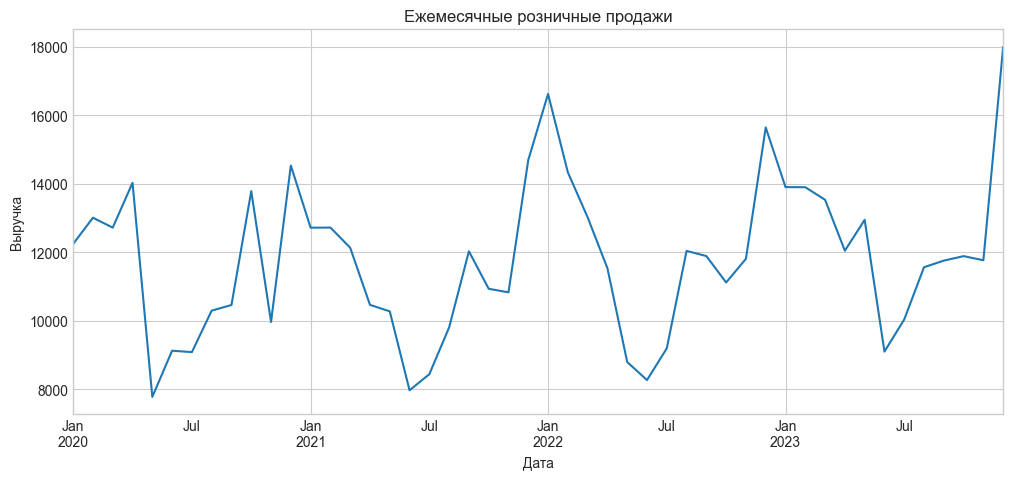

In [62]:
ax = df['SalesAmount'].plot(figsize = (12, 5), legend = None)
ax.set(title = 'Ежемесячные розничные продажи',
       xlabel = 'Дата',
       ylabel = 'Выручка');



Прослеживается сезонность, так как в январе каждого года видны характерные пики и спады в летнее время. Очень сильно бросается в глаза резкий рост выручки в декабре 2023 года, возможно были предновогодние акции или праздничная закупка перед новым годом. Выраженного тренда не наблюдается, так как выручка находится плюс минус на одном уровне

In [63]:
df['SalesAmount'].describe().round(2)

count       48.00
mean     11768.54
std       2257.54
min       7783.00
25%      10219.75
50%      11851.00
75%      13014.00
max      17996.00
Name: SalesAmount, dtype: float64

Из таблички видно, что датасет содержит 48 строк, я решила открыть его полностью и увидела, что данные ежемесячные за 4 года (гранулярность - месяц). Средняя выручка составляет 11 769 рублей. При этом разброс значений большой, так как стандартное отклонение 2258 рублей. Медиана составила 11 851 руб и близка к среднему, скорее всего не будет сильной асимметрии в распределении

межквартильный размах имеет формулу IQR = Q3 − Q1 = 13 014 - 10 219 = 2 794 руб, получила диапазон в котором находится средние 50% всех значений

Посчитаю границы выбросов:

Lower Bound = Q1 − 1.5×IQR = 10 220 − 1.5 × 2 794 = 6 029 руб

Upper Bound = Q3 + 1.5×IQR = 13 014 + 1.5 × 2 794 = 17 205 руб

Следовательно декабрь 2023 с выручкой приблизительно 18 000 руб является выбросом, так как выше верхней границы

In [64]:
print(f'Пропущенные значения: {df["SalesAmount"].isna().sum()}')


Пропущенные значения: 0


Пропущенных значений в данных нет, поэтому обработка данных не нужна

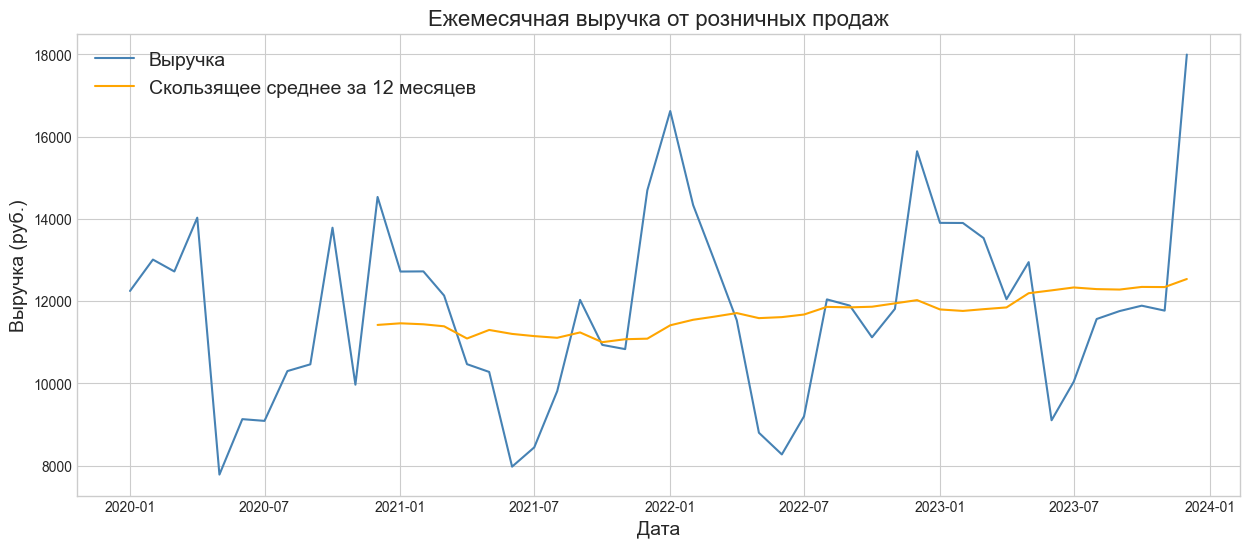

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(df['SalesAmount'], label='Выручка', color='steelblue')
plt.plot(df['SalesAmount'].rolling(window=12).mean(), label='Скользящее среднее за 12 месяцев', color='orange')

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Выручка (руб.)', fontsize=14)
plt.title('Ежемесячная выручка от розничных продаж', fontsize=16)

plt.show()


Здесь уже тренд есть, но очень слабый. Средняя выручка выросла приблизительно с 11 000 до 12 500 рублей. На предыдущем графике тренд был не заметен, видимо из-за сильных сезонных колебаний

Итог: есть явная сезонность и слабый восходящий тренд

#### Гистограмма

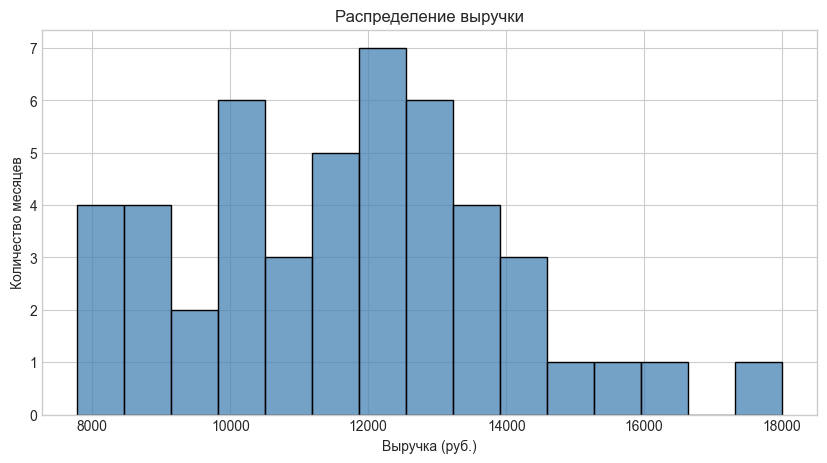

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['SalesAmount'], bins=15, color='steelblue')
plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.ylabel('Количество месяцев')
plt.show()

По гистограмме видно, что большинство месяцев выручка находилась в диапазоне от 10 000 до 13 000 руб. Один месяц с выручкой около 18 000 руб

#### Диаграмма размаха

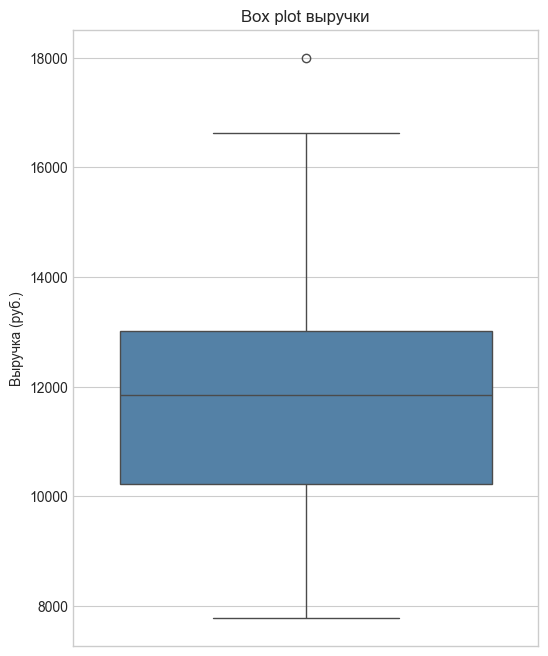

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))
sns.boxplot(y=df['SalesAmount'], color='steelblue')
plt.title('Box plot выручки')
plt.ylabel('Выручка (руб.)')
plt.show()

Синий прямоугольник охватывает средние 50% данных от 10 000 до 13 000. Линия внутри прямоугольника как раз медиана, в табличке чуть выше она как раз составила 11 850 рублей. Усы показывают нормальный диапазон значений. А кружок выше верхнего уса указывает на единичный выброс

#### Анализ внешних факторов (Promotion и HolidayMonth)

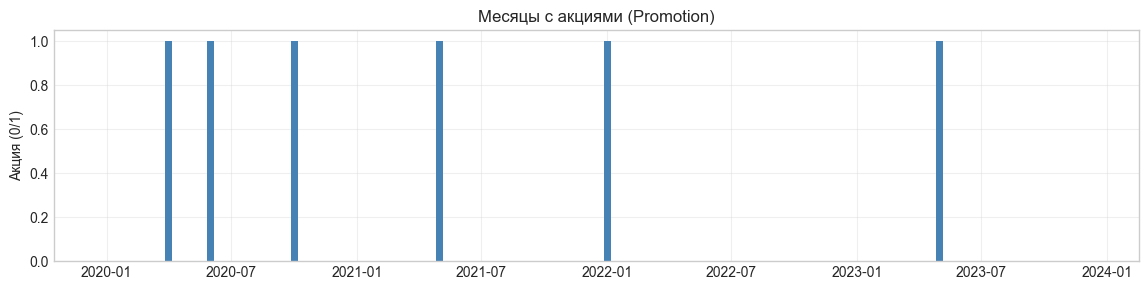

In [68]:
# Месяцы с акциями
plt.figure(figsize=(14, 3))
plt.bar(df.index, df['Promotion'], color='steelblue', width=10)
plt.title('Месяцы с акциями (Promotion)')
plt.ylabel('Акция (0/1)')
plt.grid(True, alpha=0.3)
plt.show()

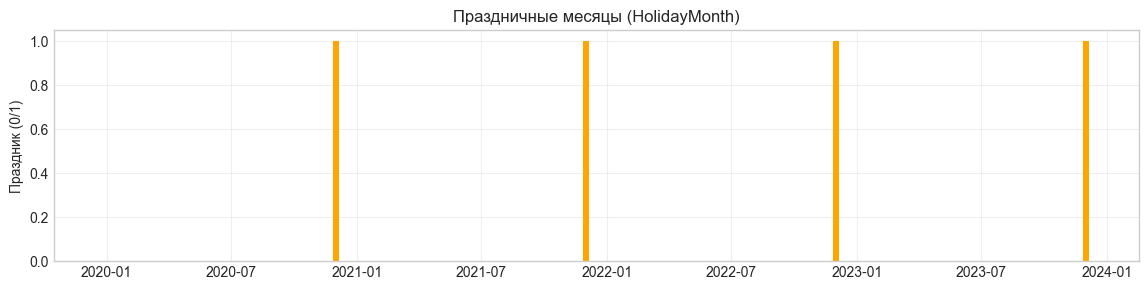

In [69]:
# Праздничные месяцы
plt.figure(figsize=(14, 3))
plt.bar(df.index, df['HolidayMonth'], color='orange', width=10)
plt.title('Праздничные месяцы (HolidayMonth)')
plt.ylabel('Праздник (0/1)')
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
# Список месяцев, где была акция или праздник
print(df[df['Promotion'] == 1])
print(df[df['HolidayMonth'] == 1])

            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-04-01        14030          1             0
2020-06-01         9131          1             0
2020-10-01        13786          1             0
2021-05-01        10279          1             0
2022-01-01        16623          1             0
2023-05-01        12949          1             0
            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-12-01        14534          0             1
2021-12-01        14696          0             1
2022-12-01        15645          0             1
2023-12-01        17996          0             1


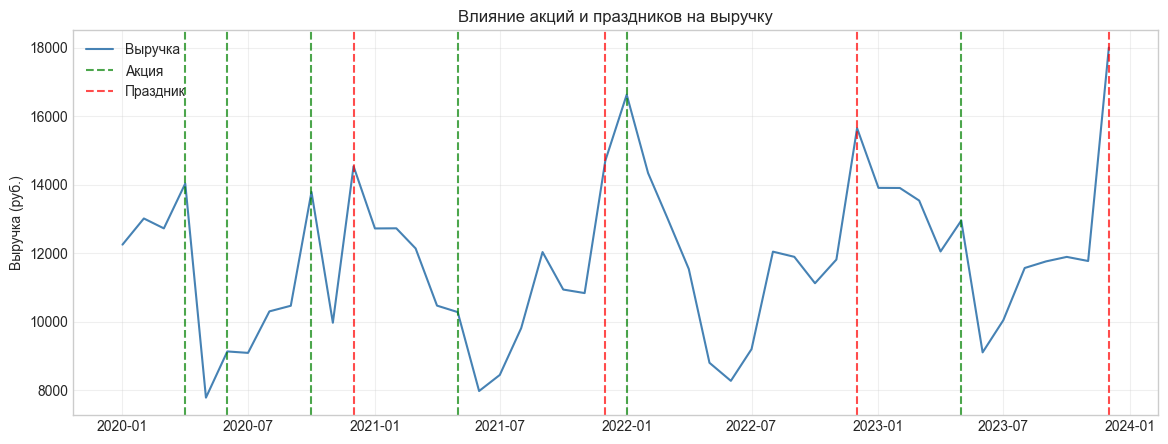

In [71]:
plt.figure(figsize=(14, 5))

# Выручка
plt.plot(df.index, df['SalesAmount'], color='steelblue', label='Выручка')

# Отмечаю акции вертикальными линиями
for date in df[df['Promotion'] == 1].index:
    plt.axvline(x=date, color='green', linestyle='--', alpha=0.7, label='Акция')

# Отмечаю праздники
for date in df[df['HolidayMonth'] == 1].index:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.7, label='Праздник')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title('Влияние акций и праздников на выручку')
plt.ylabel('Выручка (руб.)')
plt.grid(True, alpha=0.3)
plt.show()


Вижу, что акции и праздники ни разу не пересекались. Праздничные месяцы совпадают со всеми декабрями, поэтому признак HolidayMonth дублирует по сути годовую сезонность и в эти месяцы выручка выше. Что касается акций, то они проводились в 6 месяцах из всех 48 и при этом в разное время года и нет четкой закономерности, но при этом акции сопровождают всплески продаж вне сезонного пика, это апрель и октябрь 2020, май 2023

#### Теплокарта (просто интересно)

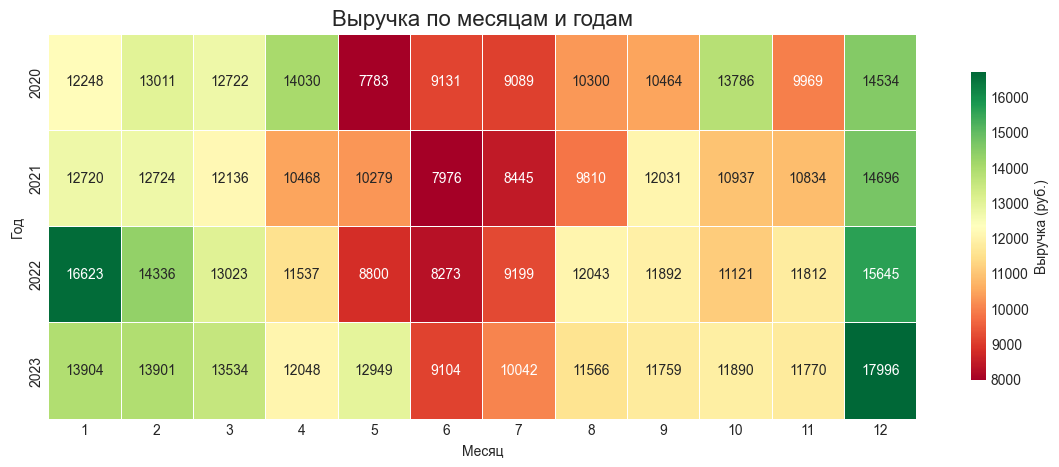

In [72]:
import seaborn as sns

# Создаю таблицу
df['Year'] = df.index.year
df['Month'] = df.index.month
pivot = df.pivot_table(values='SalesAmount', index='Year', columns='Month')

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='RdYlGn', robust=True,
            fmt='.0f', annot=True, linewidths=.5,
            cbar_kws={'shrink': .8, 'label': 'Выручка (руб.)'})

plt.title('Выручка по месяцам и годам', fontsize=16)
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.show()

На тепловой карте подтвержается сезонность уже в который раз). Каждый год летом (май-июль) выручка минимальная, а зимой (декабрь-январь) максимальная. Декабрь 2023 с выручкой 17 996 руб абсолютный рекорд за весь период. Январь 2022 также выделяется на фоне остальных январей

#### Автокорреляция

<Figure size 1500x400 with 0 Axes>

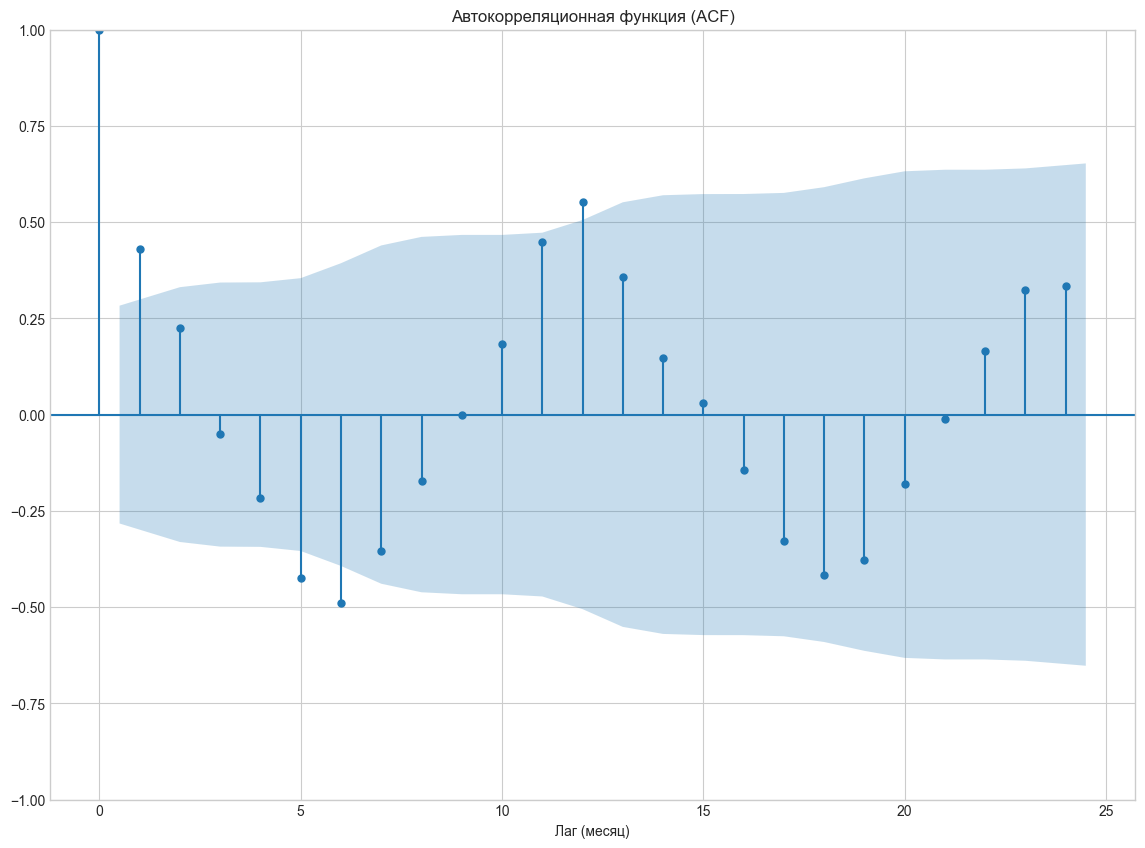

In [73]:
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 4))
plot_acf(df['SalesAmount'].values.squeeze(), lags=24)
plt.title('Автокорреляционная функция (ACF)')
plt.xlabel('Лаг (месяц)')
plt.show()

Видны максимумы на лагах 6, 12, которые говорят о сезонности год. Для построения прогноза буду рассматривать признаки с лагами 1, 5, 6, 12. Также лаг 0 = 1, что говорит идеальная корреляция с самим собой. Отрицательные значения на лагах 6 и 7 указывают на то, что летние месяцы противоположны по характеру зимним, когда зимой пик, летом спад

<Figure size 1500x400 with 0 Axes>

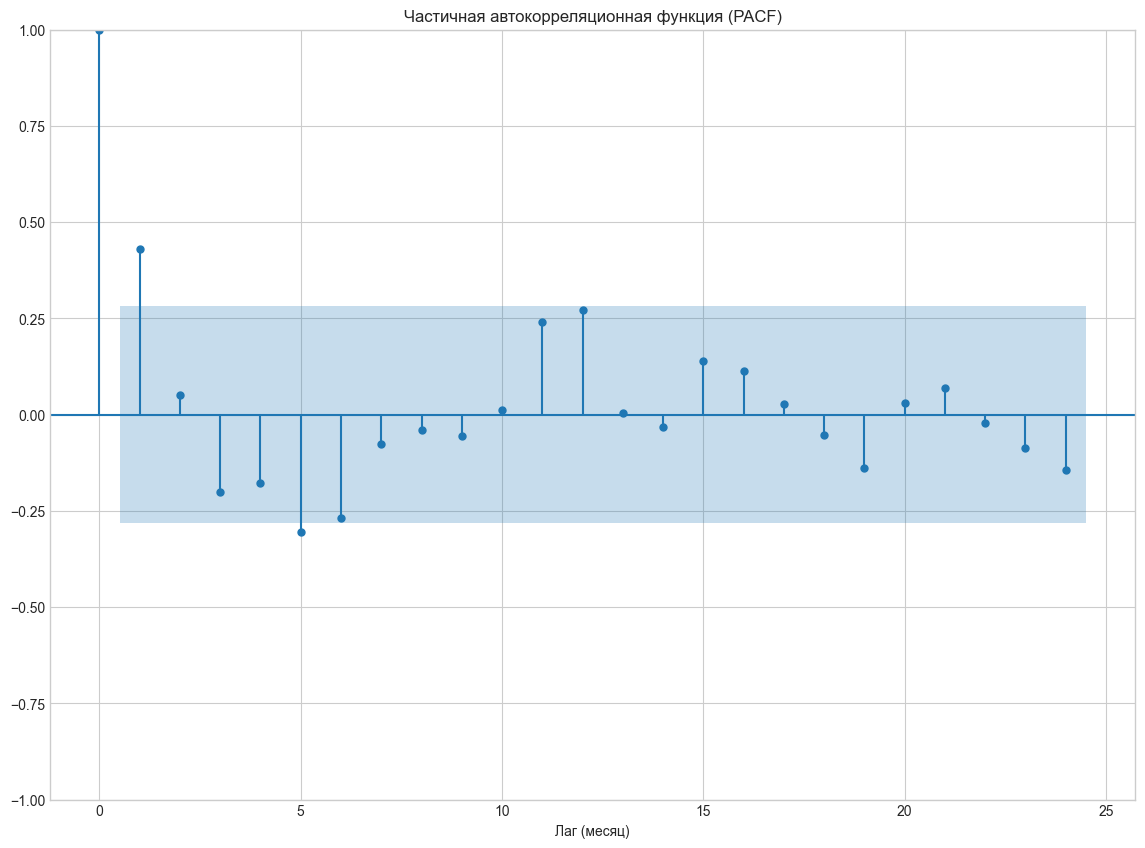

In [74]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 4))
plot_pacf(df['SalesAmount'].values.squeeze(), lags=24)
plt.title('Частичная автокорреляционная функция (PACF)')
plt.xlabel('Лаг (месяц)')
plt.show()

На графике значимый пик наблюдается только на лаге 1 значит, что текущее значение выручки напрямую зависит только от предыдущего месяца. Остальные лаги в основном находятся внутри голубой области и статистически незначим

#### Тест Дики-Фуллера

In [75]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['SalesAmount'], autolag='AIC')
print(f'p-value: {result[1]:.4f}')
print(f'Статистика теста: {result[0]:.4f}')

if result[1] < 0.05:
    print('Ряд стационарный')
else:
    print('Ряд нестационарный')

p-value: 0.0002
Статистика теста: -4.5142
Ряд стационарный


Тест Дики-Фуллера показал p-value = 0.0002, что меньше 0.05, значит ряд стационарный

1. seasonal_decompose

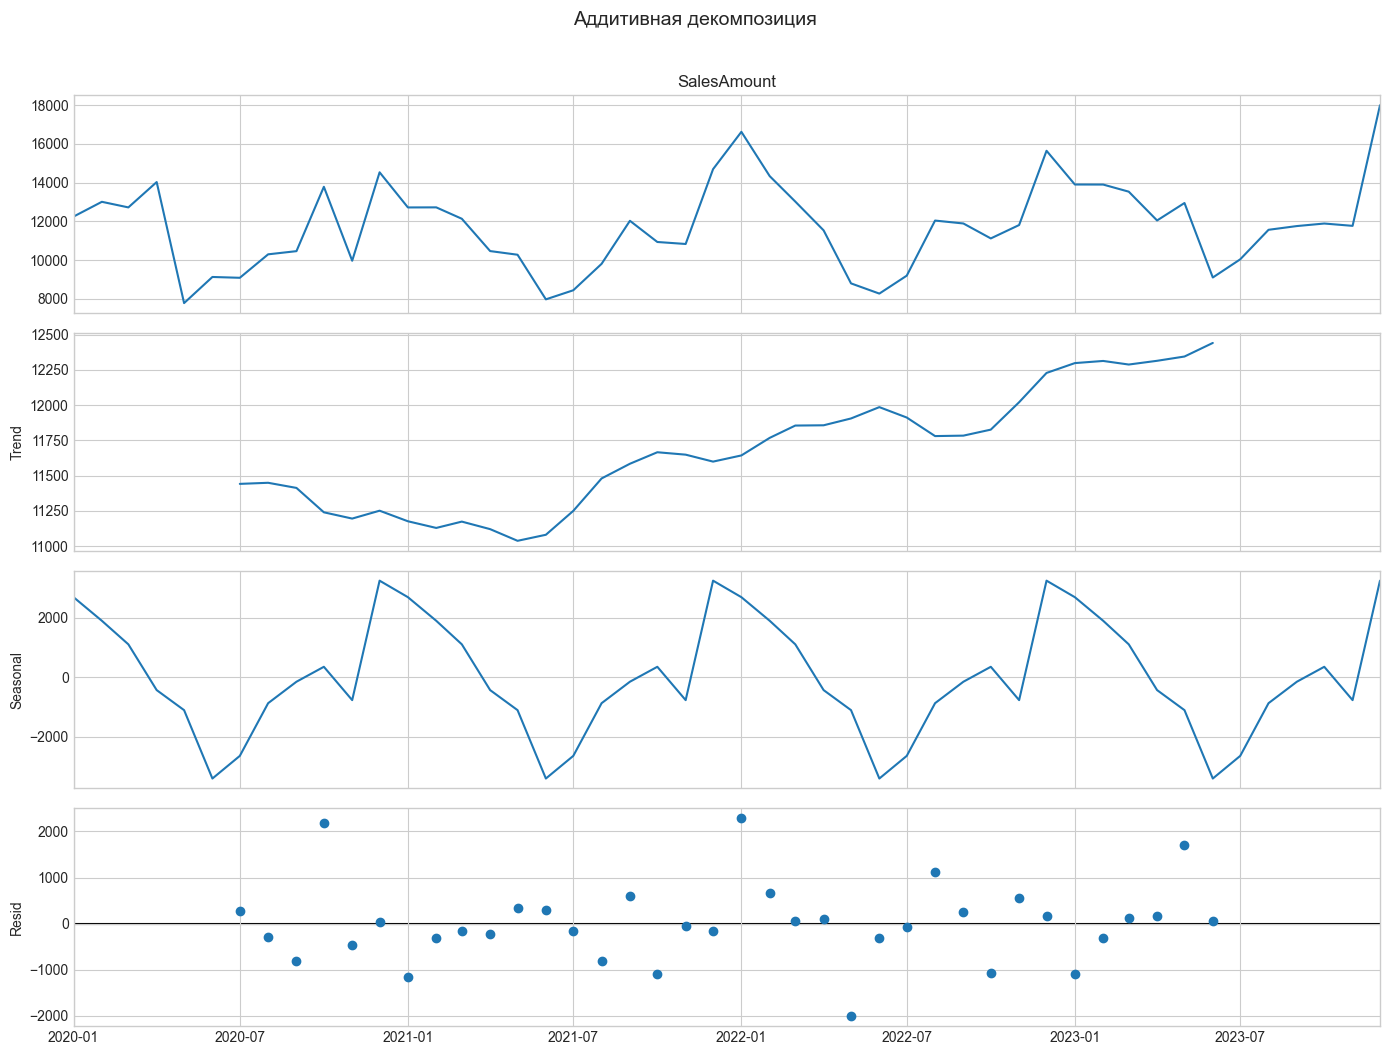

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

df = pd.read_csv('retail_sales_mock_data.csv', 
                 index_col='Date', parse_dates=True)
df.sort_index(inplace=True)

rcParams['figure.figsize'] = 14, 10

decompose = seasonal_decompose(df['SalesAmount'], model='additive', period=12)
decompose.plot()
plt.suptitle('Аддитивная декомпозиция', y=1.05, fontsize=14)
plt.show()

Тренд имеет плавный рост выручки приблизительно с 11 000 до 12 500 за 4 года. Сезонность выражена, так как повторяется годовой паттерн (пики зимой в декабре и спад летом). Что касается остатков, то они случайные, разброс остатков одинаковый на всем периоде и без перекосов

Тренд не такой гладкий, а сезонность прерывистая, может попробовать мультипликативную модель запустить на тех же данных

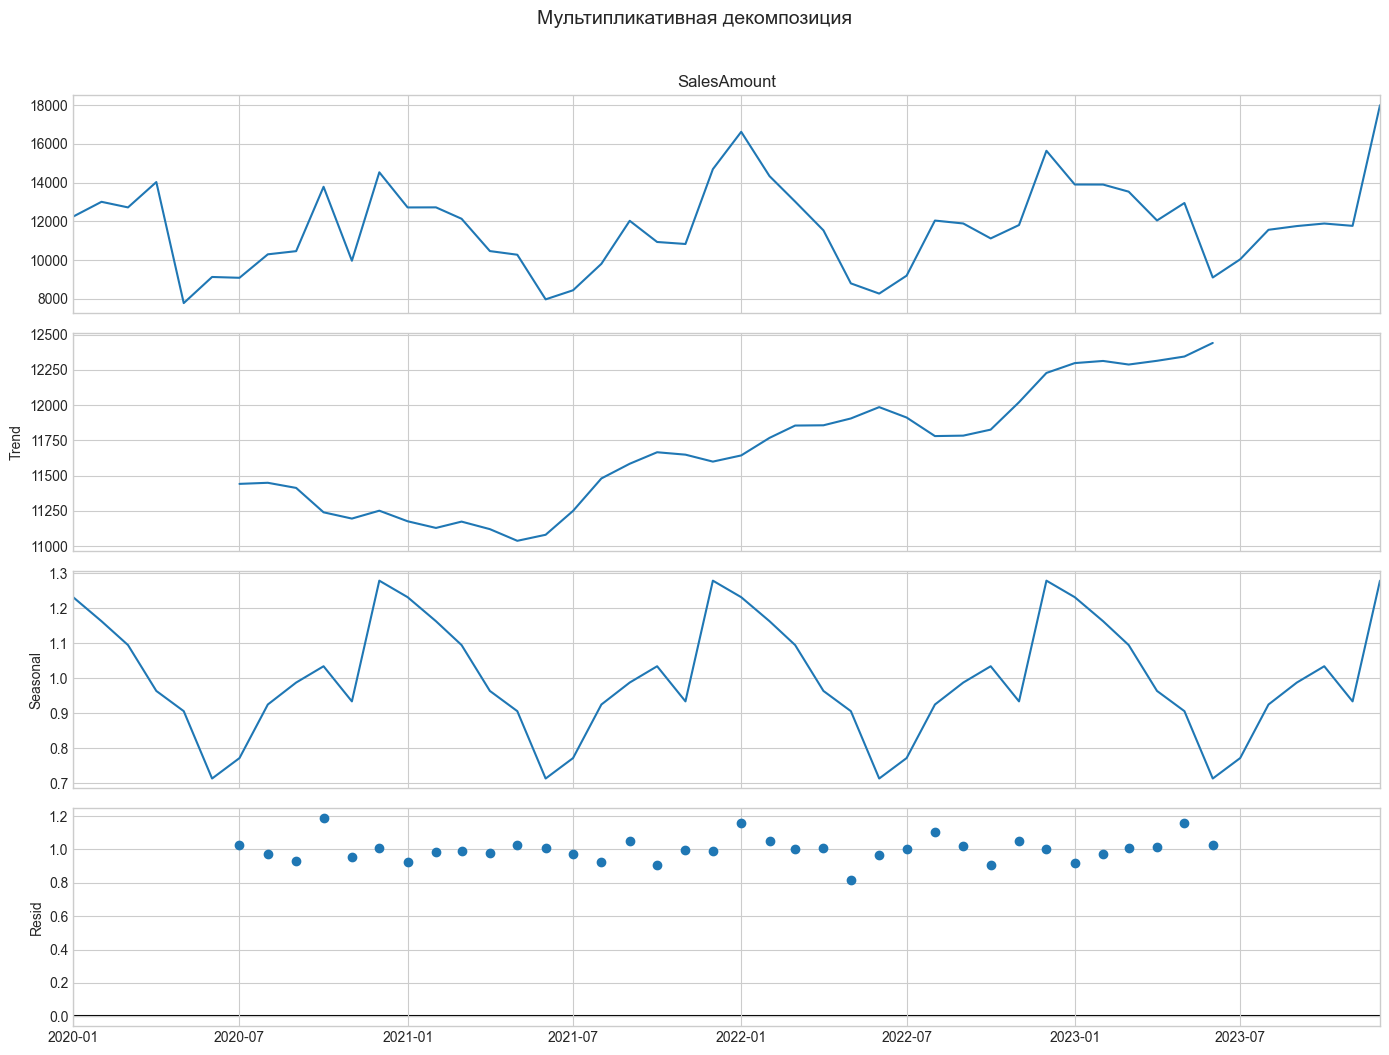

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_mult = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)
decompose_mult.plot()
plt.suptitle('Мультипликативная декомпозиция', y=1.05, fontsize=14)
plt.show()


У мультипликативной модели остатки только положительные, а это не хорошо

#### STL-декомпозиция

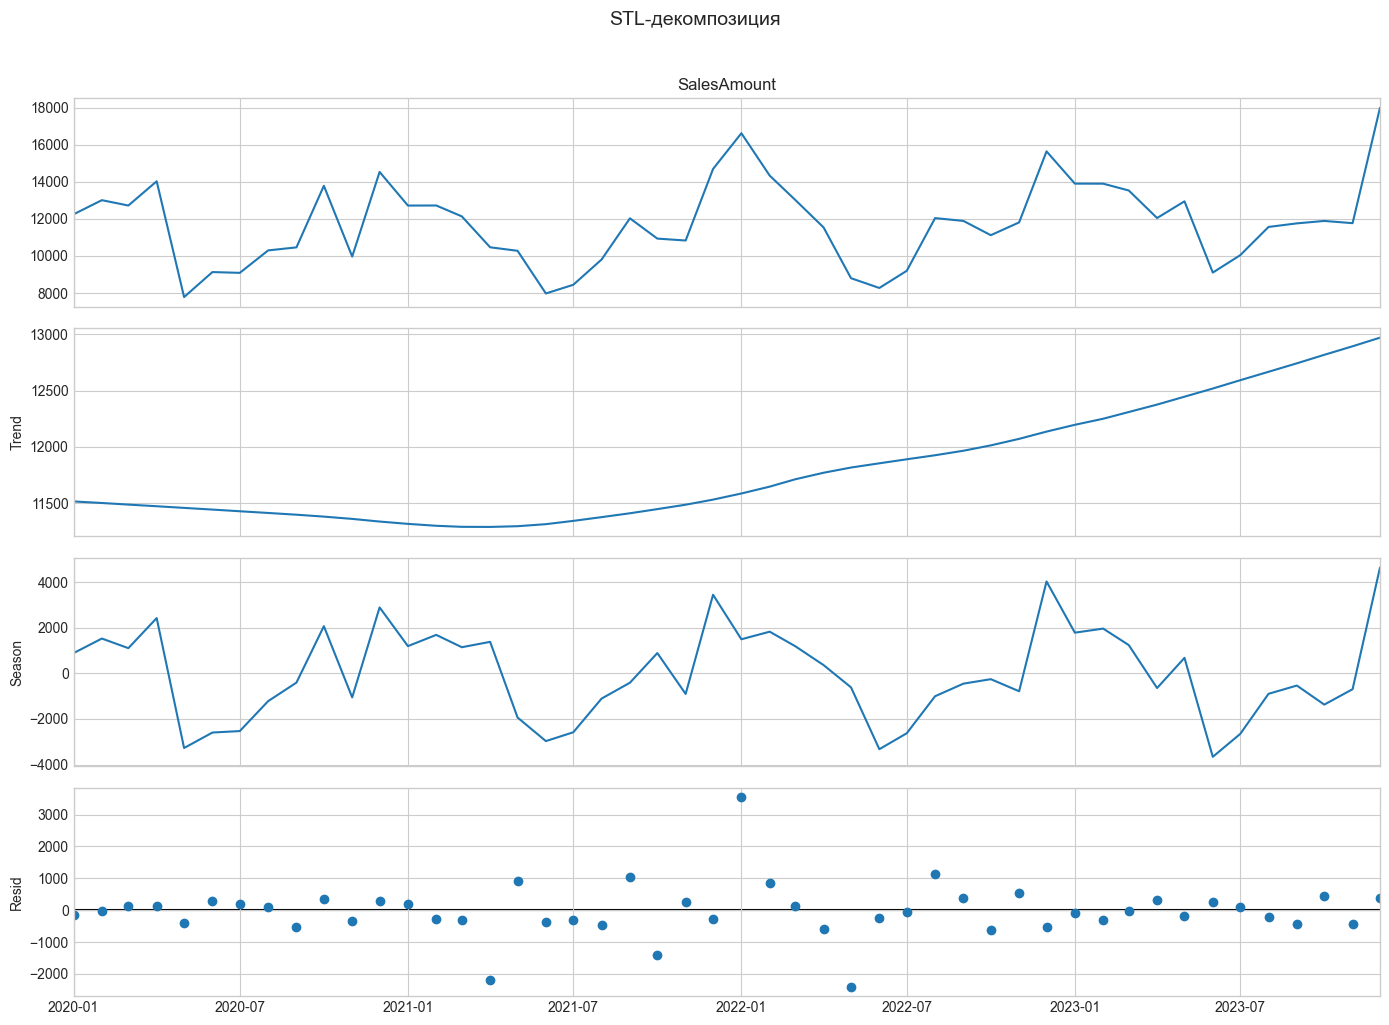

In [78]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['SalesAmount'], period=12, seasonal=13, robust=True)
result_stl = stl.fit()

fig = result_stl.plot()
fig.set_size_inches((14, 10))
plt.suptitle('STL-декомпозиция', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Что хочу отметить, график очень красивый и лучше чем были декомпозиции выше. Тренд здесь очень плавный и виден медленный рост с 11 500 до 13 000 (почти). Просто в других декопозициях (которые выше), то тренд был рваным, а здесь прям гладкая и плавная линия и он есть на всем периоде. ЧТо касается сезонности, то видно что амплитуда меняется, сначала она было поменьше(2020 - 2021), а после стала чуть выше. Остатки хорошие, но есть как будто 3 выброса: январе 2022 года (самый большой пик), и в середине 2021 и 2022

2. Спектральный анализ с применением быстрого преобразования Фурье (FFT)

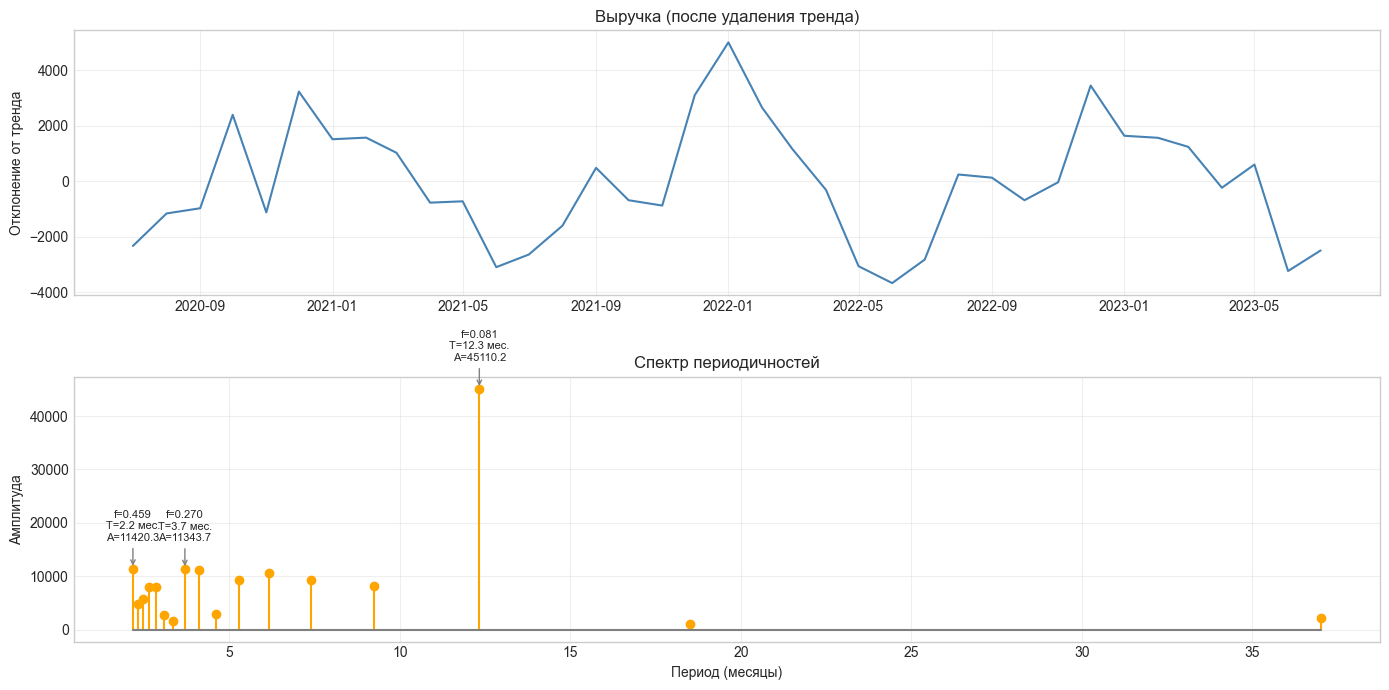

In [79]:
from scipy.fft import fft, fftfreq
import numpy as np

# Убираю тренд перед применением FFT с помощью скользящего среднего
sales_detrended = df['SalesAmount'] - df['SalesAmount'].rolling(12, center=True).mean()
sales_detrended = sales_detrended.dropna()

# Применяю быстрое преобразование Фурье
dt = 1  # шаг = 1 месяц
n = len(sales_detrended)
fft_vals = fft(sales_detrended.values)
freqs = fftfreq(n, dt)

# Беру только положительные частоты и перевожу в периоды
power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]
periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

fig, axs = plt.subplots(2, 1, figsize=(14, 7))

# Показываю ряд после удаления тренда
axs[0].plot(sales_detrended.index, sales_detrended.values, color='steelblue')
axs[0].set_title('Выручка (после удаления тренда)')
axs[0].set_ylabel('Отклонение от тренда')
axs[0].grid(True, alpha=0.3)

# Строю спектр
mask = (periods >= 2) & (periods <= 48)
axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
axs[1].set_xlabel('Период (месяцы)')
axs[1].set_ylabel('Амплитуда')
axs[1].set_title('Спектр периодичностей')
axs[1].grid(True, alpha=0.3)

# Подписываю самые сильные пики на спектре
for f in freqs[np.argsort(power)[-3:][::-1]]:
    if f > 0.01:
        period = 1/f
        amp = power[np.argmin(np.abs(freqs - f))]
        label = f'f={f:.3f}\nT={period:.1f} мес.\nA={amp:.1f}'
        axs[1].annotate(label,
                       xy=(period, amp), xytext=(0, 20), textcoords='offset points',
                       fontsize=8, ha='center',
                       arrowprops=dict(arrowstyle='->', color='gray'))


plt.tight_layout()
plt.show()


На спектре сильно выделяется один пик с периодом около 12 месяцев. Он примерно в 4 раза выше всех остальных (его амплитуда 45 110), то есть главная периодичность в данных годовая. Остальные небольшие пики (2–9 месяцев) это шум и дополнительные волны

3. Вейвлет-анализ (например, с использованием вейвлета Морле или Добеши)

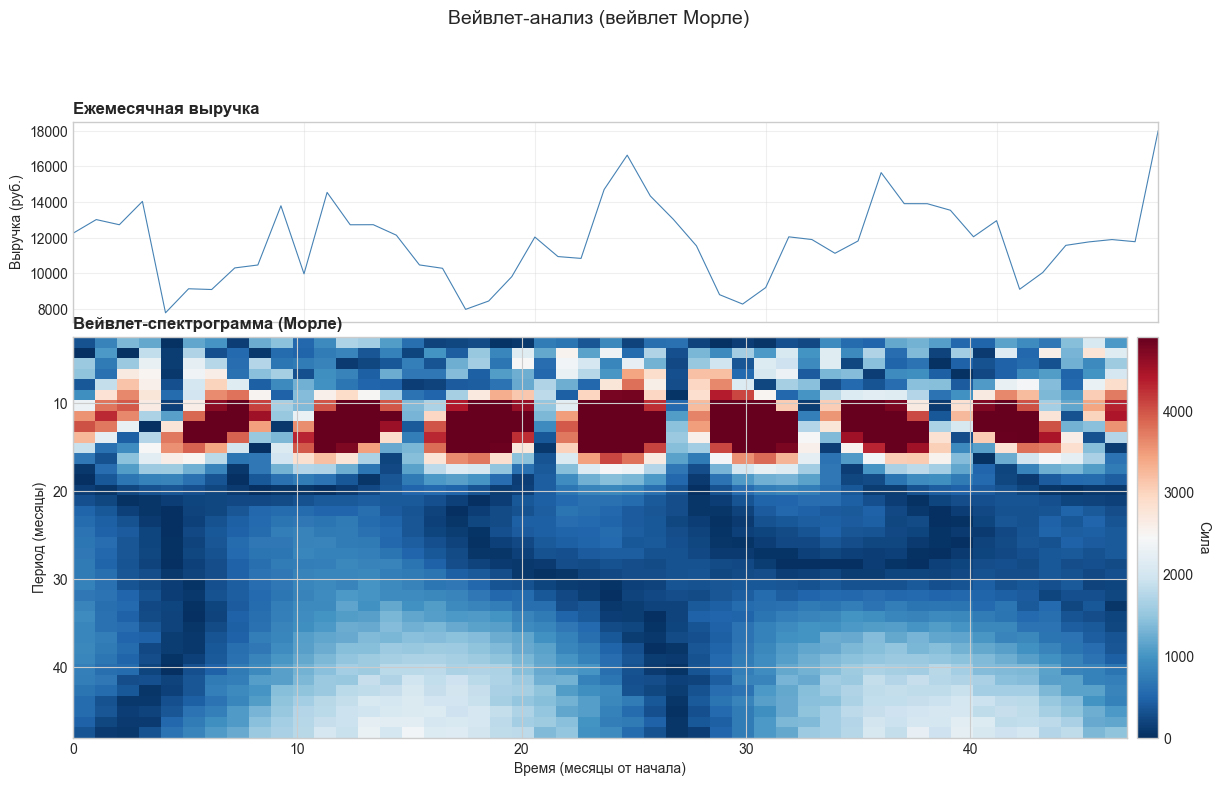

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('seaborn-v0_8-whitegrid')

# Подготовка данных
signal = df['SalesAmount'].values
signal_centered = signal - signal.mean() 
t = np.arange(len(signal))  # индексы месяцев
sampling_period = 1

# Вейвлет-преобразование Морле
wavelet = 'morl'
scales = np.arange(1, 48)
coefficients, frequencies = pywt.cwt(signal_centered, scales, wavelet, sampling_period=sampling_period)   

# Подготовка спектрограммы
mask = frequencies > 0
periods = 1 / frequencies[mask]
coefficients_abs = np.abs(coefficients[mask, :])
period_mask = (periods >= 2) & (periods <= 48)
periods_plot = periods[period_mask]
coefficients_plot = coefficients_abs[period_mask, :]

# Визуализация
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                        gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.05})

# Исходный сигнал
axs[0].plot(t, signal, color='steelblue', linewidth=0.8)
axs[0].set_title('Ежемесячная выручка', fontweight='bold', loc='left')
axs[0].set_ylabel('Выручка (руб.)')
axs[0].grid(True, alpha=0.3)

# Спектрограмма
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="2%", pad=0.1)

im = axs[1].imshow(coefficients_plot,
                   extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
                   aspect='auto', cmap='RdBu_r',
                   vmin=0, vmax=np.percentile(coefficients_plot, 95))
axs[1].set_title('Вейвлет-спектрограмма (Морле)', fontweight='bold', loc='left')
axs[1].set_ylabel('Период (месяцы)')
axs[1].set_xlabel('Время (месяцы от начала)')

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Сила', rotation=270, labelpad=12)

plt.suptitle('Вейвлет-анализ (вейвлет Морле)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


На спектрограмме я вижу яркие красно-оранжевые пятна в верхней части графика на периодах около 8–15 месяцев. Полоса находится на уровне около 12 месяцев по вертикальной оси показывает годовую сезонность, она есть на протяжении всех 4 лет. По горизонтали пятна повторяются примерно каждые 6 месяцев, потому что вейвлет Морле реагирует отдельно на пики (декабрь) и провалы (июнь) сезонной волны. Пятна выглядят одинаковыми. Что касается нижней части, то периоды 20–48 месяцев есть слабые белёсые пятна это слабый сигнал на длинных периодах

#### Сравнение результатов методов, их применимости и преимущества и недоастатки

Я применила три метода декомпозиции чтобы лучше понять структуру ряда.

Начала с классической аддитивной декомпозиции через seasonal_decompose. Этот метод оказался самым простым и наглядным, он разбил ряд на тренд, сезонность и остатки. Я увидела что тренд постепенно растёт примерно с 11 000 до 12 500 руб. за 4 года, сезонность чётко повторяется каждый год с пиками зимой и спадами летом, а остатки небольшие и разброс у них одинаковый на всём периоде. Также попробовала мультипликативную модель, но она дала хуже результат, остатки были смещены выше 1, поэтому аддитивная подошла лучше. Главный минус этого метода в том что он не может показать меняется ли сезонность со временем.

Второй метод это спектральный анализ FFT. Перед применением я убрала тренд через скользящее среднее. FFT нашёл один главный пик на периоде 12 месяцев с амплитудой 45 110, что в разы больше всех остальных пиков. Это математически подтвердило годовую сезонность. Мелкие пики в начале спектра на периодах 2-5 месяцев оказались не реальными циклами, а гармониками основного пика. Минус этого метода в том что он не показывает когда именно в ряду проявляется тот или иной цикл.

Третий метод это вейвлет-анализ с вейвлетом Морле. Он единственный показал как сезонность ведёт себя во времени. На спектрограмме красные пятна одинаковые на протяжении всех 4 лет, значит сезонность не усиливается и не ослабевает. Слабые пятна в нижней части скорее всего отражают слабый тренд. Из минусов этот метод сложнее всего читать и интерпретировать.

Все три метода показали одно и то же, в данных есть устойчивая годовая сезонность с периодом 12 месяцев

## 2.2. Построение прогнозных моделей

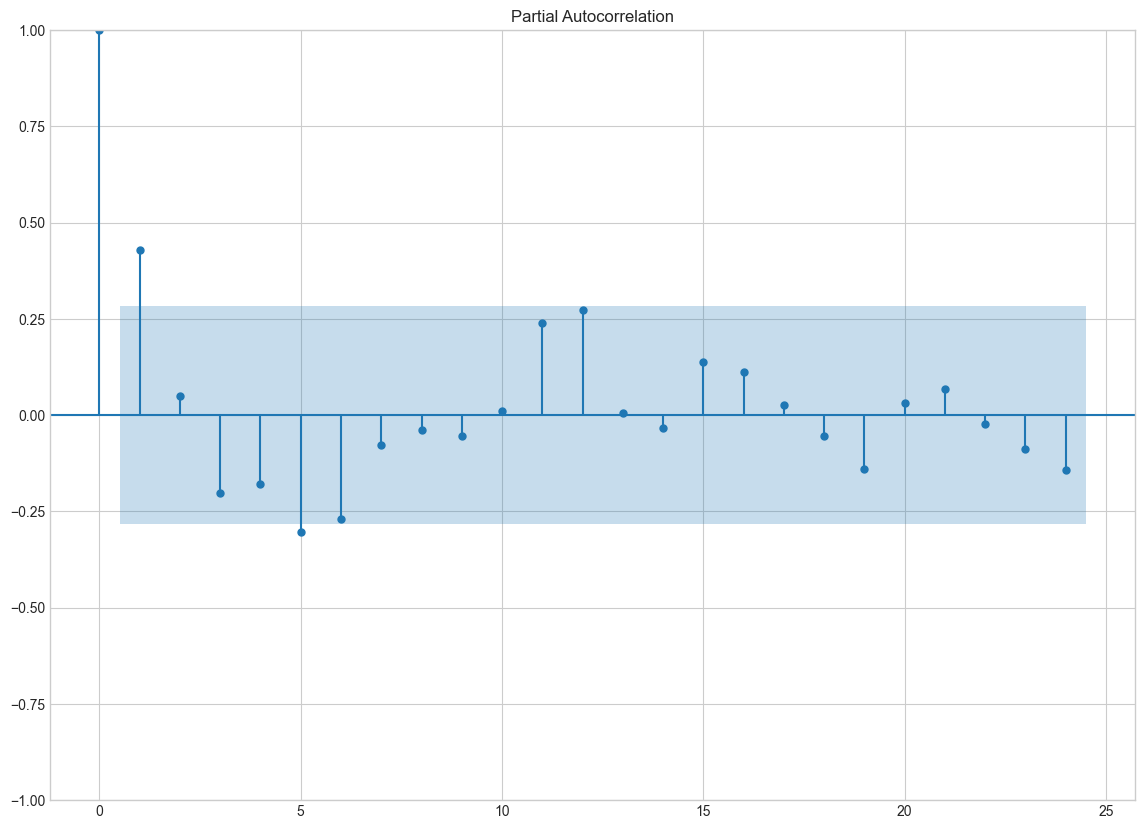

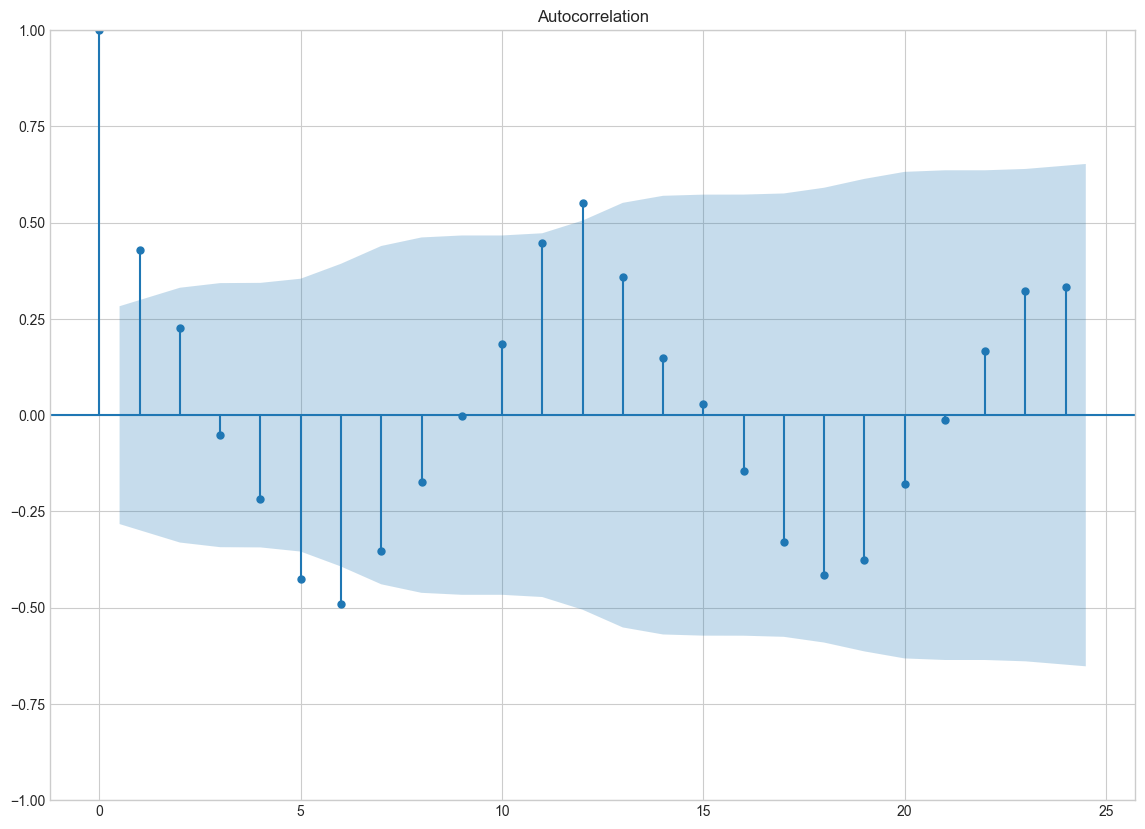

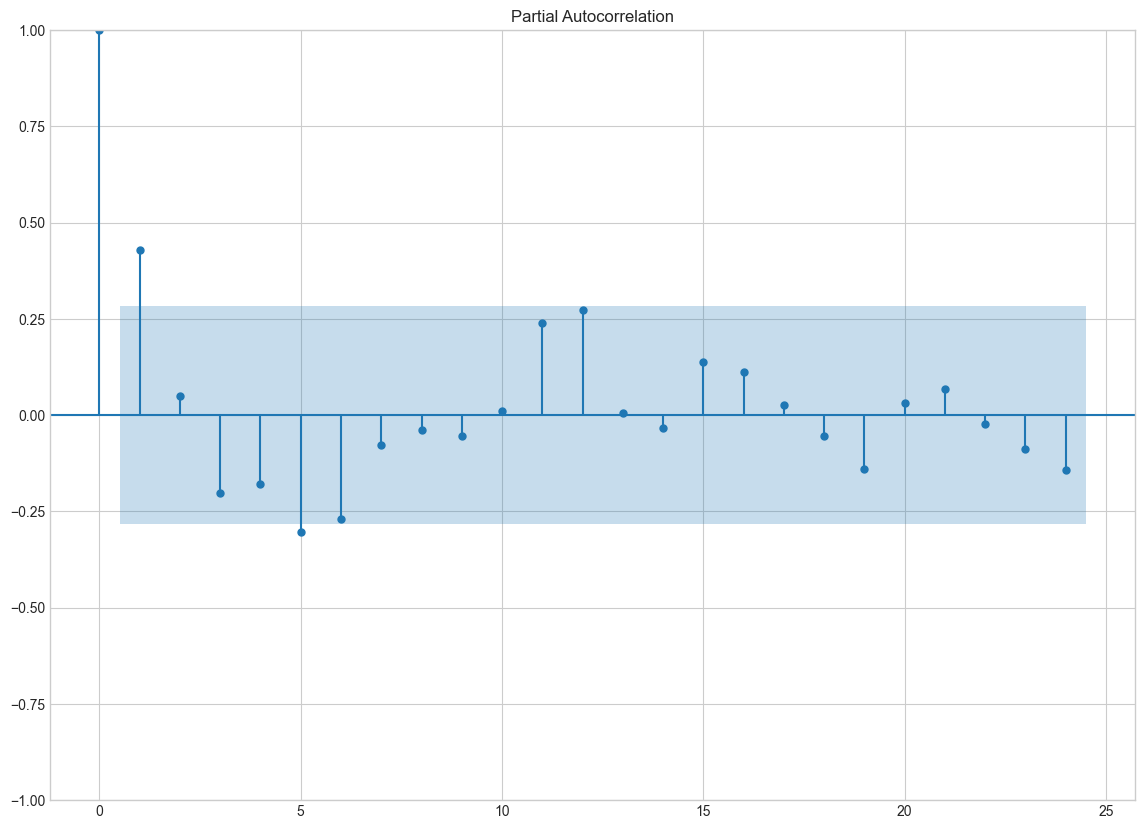

In [81]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['SalesAmount'].values.squeeze(), lags=24)
plot_pacf(df['SalesAmount'].values.squeeze(), lags=24)

Делю данные на обучающую и тестовую выборку. Первые 36 месяцев (это получается 2020-2022 года), а оставшиеся 12 месяцев (2023 год) отправлю на тест

In [82]:
train = df['SalesAmount'][:-12]
test = df['SalesAmount'][-12:]
print(f'Обучающая выборка: {len(train)} месяцев')
print(f'Тестовая выборка: {len(test)} месяцев')

Обучающая выборка: 36 месяцев
Тестовая выборка: 12 месяцев


Пытаюсь вручную подобрать параметры для ARIMA. Первый параметр(p) - авторегрессия, для этого я повторно вывела графики чуть выше. По графику видно, что в прогноз пойдут лаги: 1, 5, 6, 12 (высоки пики у 6 и 12 лага). Второй параметр (d) отвечает за интегрирование, так как тест Дики Фуллера показал что ряд стационарен p-value = 0.0002 < 0.05, следовательно ряд является стационарным. Третий параметр (q) - модель скользящего среднего, учитывает ошибки прошлых прогнозов

С d всё понятно, дифференцировать не надо, поэтому он равен 0

p и q подбирается с помощью графиков ACF и PACF, где график ACF помогает определить параметр q (для MA), а график PACF помогает определить параметр p (для AR)

На PACF ищу точку, где столбик впервые обрывается за пределами синей области (незначимой). Это лаг будет кандидатом для p. На ACF ищу аналогично для q

У меня получилось: 

p = 5

q = 6

12 лаг для q я не стала брать, так как датасет и так маленький и 12 было бы жестко

In [83]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(5, 0, 6))
result_arima = model_arima.fit()

print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(5, 0, 6)   Log Likelihood                -334.952
Date:                Wed, 07 Oct 2026   AIC                            695.905
Time:                        20:43:44   BIC                            716.491
Sample:                    01-01-2020   HQIC                           703.090
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04     37.317    308.489      0.000    1.14e+04    1.16e+04
ar.L1          0.7434      0.078      9.498      0.000       0.590       0.897
ar.L2         -0.2684      0.060     -4.494      0.0

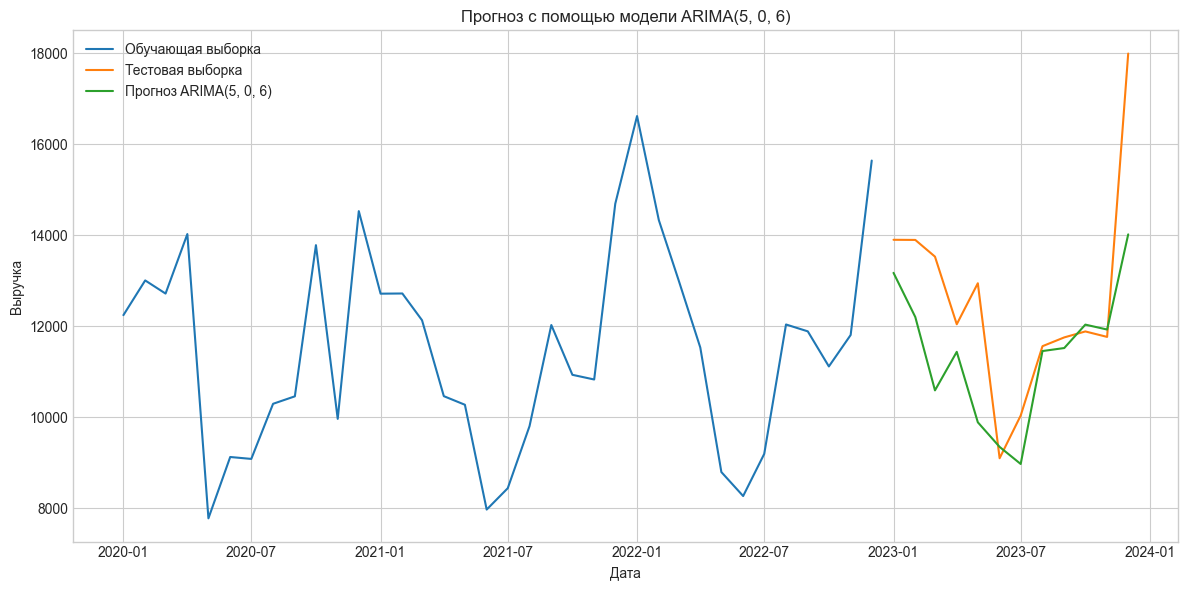

In [84]:
# Строю прогноз на тестовый период (12 месяцев)
forecast_arima = result_arima.predict(start=len(train), end=len(train) + len(test) - 1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(5, 0, 6)')
plt.title('Прогноз с помощью модели ARIMA(5, 0, 6)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()

Зеленая линия, отвечающая за прогноз хорошо учитывает особенности, если смотреть на тестовую линию. Также учитывается сезонность, так как виден спад в июле 2023 года, а в конце года предсказал подъем как и должно быть, хотя декабрьский пик немного недооценила

Автоматический подбор параметров

In [85]:
from pmdarima import auto_arima

model_auto = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=6,
    d=None,
    seasonal=False,
    trace=True,
    stepwise=True
)

print(f"\nОптимальный порядок: {model_auto.order}")
print(f"AIC = {model_auto.aic():.3f}")


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.739, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=664.123, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=744.544, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=664.726, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=665.549, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=653.040, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=660.355, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=655.042, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=655.105, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=655.621, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=656.320, Time=0.09 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 0.590 seconds

Оптимальный порядок: (1, 0, 0)
AIC = 653.040


Проверка с предложенным вариантом автоподбора

In [86]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1, 0, 0), trend='c')
result_arima = model_arima.fit()

print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -323.535
Date:                Wed, 07 Oct 2026   AIC                            653.070
Time:                        20:43:45   BIC                            657.821
Sample:                    01-01-2020   HQIC                           654.728
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    669.394     17.197      0.000    1.02e+04    1.28e+04
ar.L1          0.4941      0.190      2.601      0.009       0.122       0.866
sigma2       3.81e+06   9.21e+05      4.136      0.0

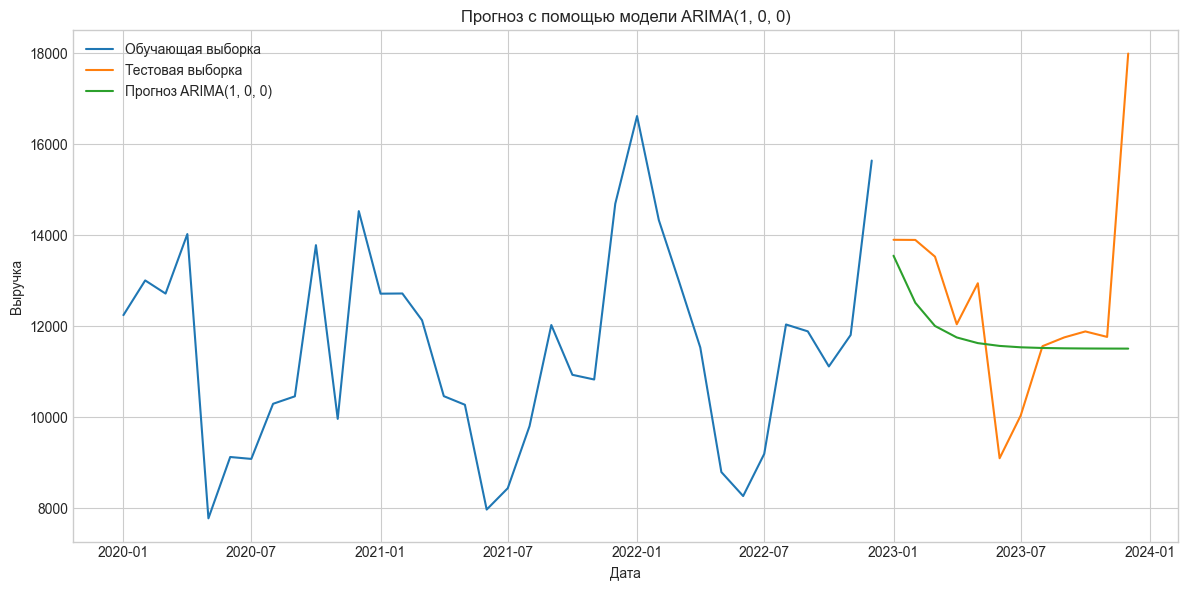

In [87]:
forecast_arima = result_arima.predict(start=len(train), end=len(train) + len(test) - 1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA(1, 0, 0)')
plt.title('Прогноз с помощью модели ARIMA(1, 0, 0)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()

Сравню результаты ручного подбора и автоподбора: в данном случае автоподбор сработал плохо. Зеленая линия ARIMA(1,0,0) просто уходит в плавный спуск без колебаний и не отражает природу данных. А вот у ARIMA(5,0,6) наоборот, описывает природу данных, так как спускается с реальными данными летом, поднимается к осени и почти догоняет до значения в декабре, здесь прогноз более реален. Но из-за сложности модели пришлось пожертвовать немного AIC (с 653 до 695)

ARIMA не учитывает сезонность, поэтому воспользуюсь SARIMAX, которая добавляет сезонные параметры (P, D, Q, s), где s-сезонность, и так как сезонность у меня по eda годовая, то s=12. Также в данных у меня есть праздники и акции, которые относятся к экзогенным данным, которые не случаются часто, т.е внешние факторы, которые так или иначе будут влиять на выручку

#### Экзогенные данные

разобью экзогенные данные тоже на обучающую и тестовую выборки

In [88]:
exog_train = df[['Promotion', 'HolidayMonth']][:-12]
exog_test  = df[['Promotion', 'HolidayMonth']][-12:]

print('Экзогенные переменные (обучение):')
print(exog_train.tail())
print(f'\nРазмер: {exog_train.shape}')

print('\nЭкзогенные переменные (тест):')
print(exog_test)
print(f'\nРазмер: {exog_test.shape}')

Экзогенные переменные (обучение):
            Promotion  HolidayMonth
Date                               
2022-08-01          0             0
2022-09-01          0             0
2022-10-01          0             0
2022-11-01          0             0
2022-12-01          0             1

Размер: (36, 2)

Экзогенные переменные (тест):
            Promotion  HolidayMonth
Date                               
2023-01-01          0             0
2023-02-01          0             0
2023-03-01          0             0
2023-04-01          0             0
2023-05-01          1             0
2023-06-01          0             0
2023-07-01          0             0
2023-08-01          0             0
2023-09-01          0             0
2023-10-01          0             0
2023-11-01          0             0
2023-12-01          0             1

Размер: (12, 2)


In [89]:
print(df[['Promotion', 'HolidayMonth']].sum())

Promotion       6
HolidayMonth    4
dtype: int64


In [90]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Перебираю комбинации несезонных и сезонных параметров
nonseasonal_orders = [(0,0,0), (1,0,0), (0,0,1), (1,0,1), (5,0,6)]
seasonal_orders    = [(1,1,0,12), (2,1,0,12), (1,1,1,12), (0,1,1,12)]

aic_values = []
bic_values = []
params = []

for order in nonseasonal_orders:
    for s_order in seasonal_orders:
        model = SARIMAX(train, exog=exog_train, order=order, seasonal_order=s_order).fit(disp=False)
        aic_values.append(model.aic)
        bic_values.append(model.bic)
        params.append((order, s_order))
        print(f'SARIMAX{order}{s_order} — AIC: {model.aic:.2f}, BIC: {model.bic:.2f}')

best_aic = params[np.argmin(aic_values)]
best_bic = params[np.argmin(bic_values)]
print(f'\nЛучшая модель по AIC: SARIMAX{best_aic[0]}{best_aic[1]}')
print(f'Лучшая модель по BIC: SARIMAX{best_bic[0]}{best_bic[1]}')

SARIMAX(0, 0, 0)(1, 1, 0, 12) — AIC: 406.99, BIC: 411.70
SARIMAX(0, 0, 0)(2, 1, 0, 12) — AIC: 394.00, BIC: 399.89
SARIMAX(0, 0, 0)(1, 1, 1, 12) — AIC: 402.48, BIC: 408.37
SARIMAX(0, 0, 0)(0, 1, 1, 12) — AIC: 406.29, BIC: 411.00
SARIMAX(1, 0, 0)(1, 1, 0, 12) — AIC: 406.20, BIC: 412.09
SARIMAX(1, 0, 0)(2, 1, 0, 12) — AIC: 394.61, BIC: 401.67
SARIMAX(1, 0, 0)(1, 1, 1, 12) — AIC: 401.69, BIC: 408.76
SARIMAX(1, 0, 0)(0, 1, 1, 12) — AIC: 406.28, BIC: 412.17
SARIMAX(0, 0, 1)(1, 1, 0, 12) — AIC: 406.24, BIC: 412.13
SARIMAX(0, 0, 1)(2, 1, 0, 12) — AIC: 394.58, BIC: 401.65
SARIMAX(0, 0, 1)(1, 1, 1, 12) — AIC: 401.99, BIC: 409.06
SARIMAX(0, 0, 1)(0, 1, 1, 12) — AIC: 406.29, BIC: 412.18
SARIMAX(1, 0, 1)(1, 1, 0, 12) — AIC: 408.19, BIC: 415.26
SARIMAX(1, 0, 1)(2, 1, 0, 12) — AIC: 394.28, BIC: 402.53
SARIMAX(1, 0, 1)(1, 1, 1, 12) — AIC: 397.51, BIC: 405.75
SARIMAX(1, 0, 1)(0, 1, 1, 12) — AIC: 408.32, BIC: 415.39
SARIMAX(5, 0, 6)(1, 1, 0, 12) — AIC: 406.92, BIC: 424.59
SARIMAX(5, 0, 6)(2, 1, 0, 12) —

In [91]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    train,
    exog=exog_train,
    order=(5, 0, 6),
    seasonal_order=(2, 1, 0, 12)
)
result_sarimax = model_sarimax.fit(disp=False)

print(result_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         SalesAmount   No. Observations:                   36
Model:             SARIMAX(5, 0, 6)x(2, 1, [], 12)   Log Likelihood                -187.875
Date:                             Wed, 07 Oct 2026   AIC                            407.750
Time:                                     20:44:02   BIC                            426.599
Sample:                                 01-01-2020   HQIC                           412.751
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2574.0008   1108.340      2.322      0.020     401.693    4746.308
HolidayMonth  8.447e-

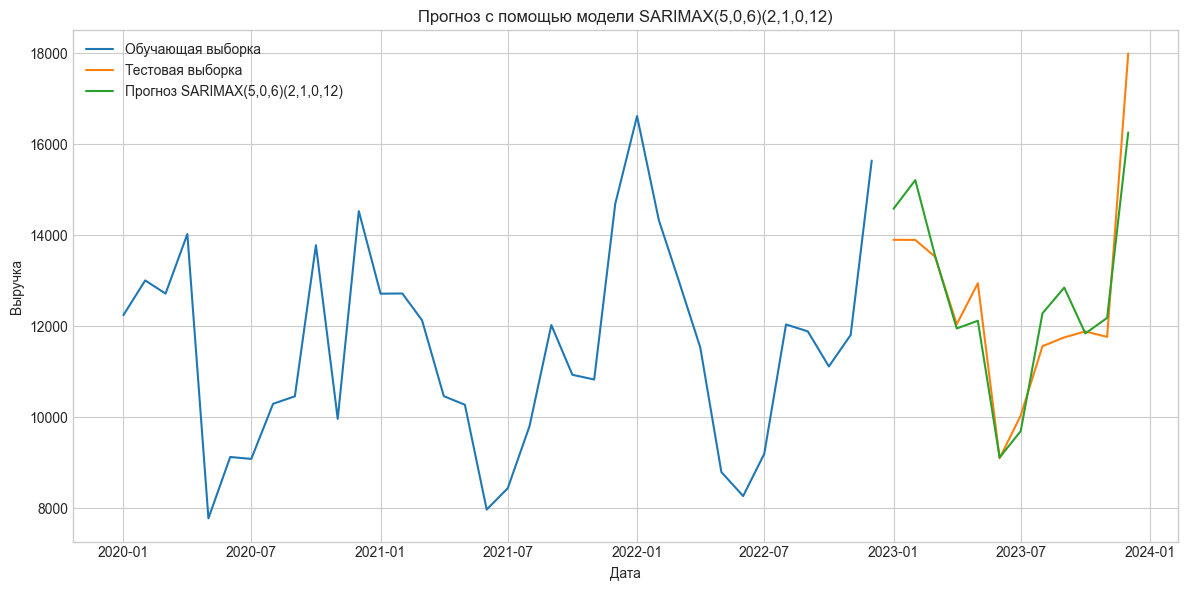

In [92]:
forecast_sarimax = result_sarimax.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    exog=exog_test
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_sarimax, label='Прогноз SARIMAX(5,0,6)(2,1,0,12)')
plt.title('Прогноз с помощью модели SARIMAX(5,0,6)(2,1,0,12)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()


Зелёная линия следует за реальными значениями и улавливает общую форму сезонных колебаний и много где совпадает с тестовой линией. В начале тестового периода (январь 2023) модель правильно предсказала пик около 14000. Затем спад в середине года тоже показан верно. К концу 2023 года модель предсказала подъём, хотя реальный декабрьский пик около 18000 она немного недооценила и остановилась примерно на 15500. Думаю это связано с тем что в декабре был праздничный месяц и модель не до конца учла насколько сильно это влияет на выручку при таком маленьком датасете

Хочу глянуть что предложит автоподбор

In [93]:
import warnings
warnings.filterwarnings('ignore')
from pmdarima import auto_arima

model_auto_sarima = auto_arima(
    train,
    exogenous=exog_train,
    start_p=0, max_p=5,
    start_q=0, max_q=6,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"\nЛучшие параметры: {model_auto_sarima.order}{model_auto_sarima.seasonal_order}")
print(f"AIC = {model_auto_sarima.aic():.3f}")


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=425.761, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=426.130, Time=0.08 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=425.628, Time=0.08 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=424.616, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=424.339, Time=0.04 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=423.373, Time=0.27 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=426.322, Time=0.15 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=425.423, Time=0.14 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(0,0,0)(2,1,0)[12]             : AIC=422.538, Time=0.07 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=425.114, Time=0.04 sec
 ARIMA(0,0,0)(2,1,1)[12]             : AIC=424.332, Time=0.11 sec
 ARIMA(0,0,0)(1,1,1)[12]             : AIC=in

Переобучу саримакс с найденными параметрами

In [94]:
model_sarimax = SARIMAX(
    train,
    exog=exog_train,
    order=(0, 0, 0),
    seasonal_order=(2, 1, 0, 12)
)
result_sarimax = model_sarimax.fit(disp=False)

print(result_sarimax.summary())


                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 1, 0, 12)   Log Likelihood                -192.001
Date:                  Wed, 07 Oct 2026   AIC                            394.001
Time:                          20:44:06   BIC                            399.891
Sample:                      01-01-2020   HQIC                           395.564
                           - 12-01-2022                                         
Covariance Type:                    opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2574.0000    446.419      5.766      0.000    1699.034    3448.966
HolidayMonth  3.165e-07    2.9e+04   1.09e-11      1.000   -5.68e+04    5.68e+04
ar.S.L12      2.638e-05     

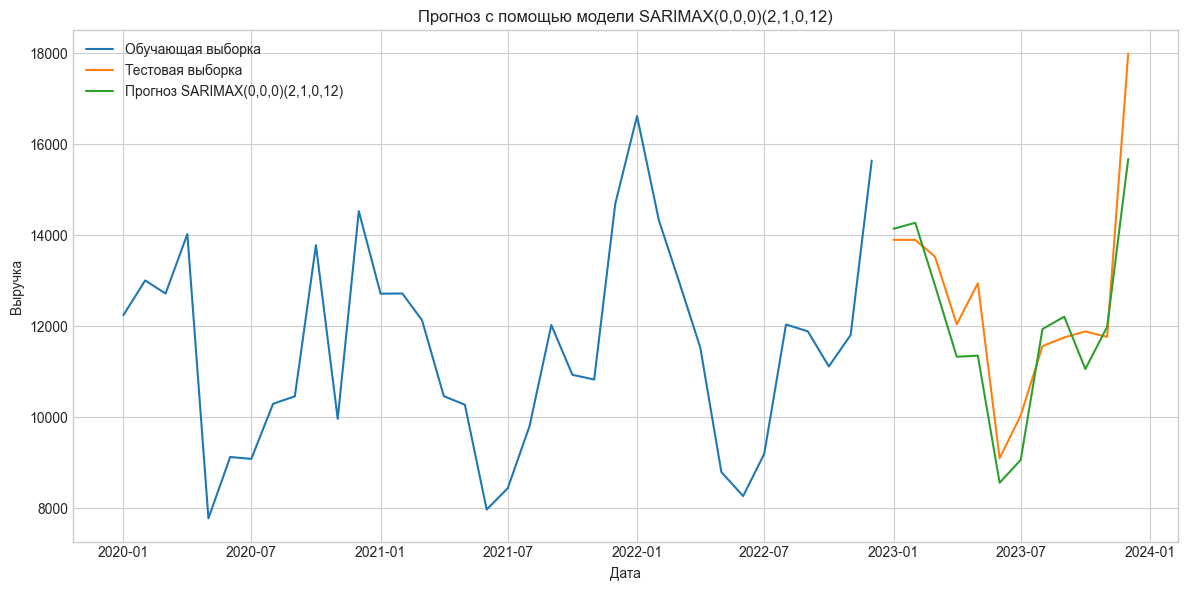

In [95]:
forecast_sarimax = result_sarimax.predict(
    start=len(train),
    end=len(train) + len(test) - 1,
    exog=exog_test
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=train, label='Обучающая выборка')
sns.lineplot(data=test, label='Тестовая выборка')
sns.lineplot(data=forecast_sarimax, label='Прогноз SARIMAX(0,0,0)(2,1,0,12)')
plt.title('Прогноз с помощью модели SARIMAX(0,0,0)(2,1,0,12)')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend()
plt.tight_layout()
plt.show()


Плюс минус тоже самое, если сравнивать с предыдущем графиком. Единственное, информационный критерий AIC снизился с 655 до 422

Интересно глянуть график с доверительным интервалом

Я дообучила финальную модель SARIMAX на всех доступных данных и построила прогноз на 12 месяцев вперёд. Для будущего периода экзогенные переменные я задала нулями, так как заранее неизвестно когда будут акции и праздники

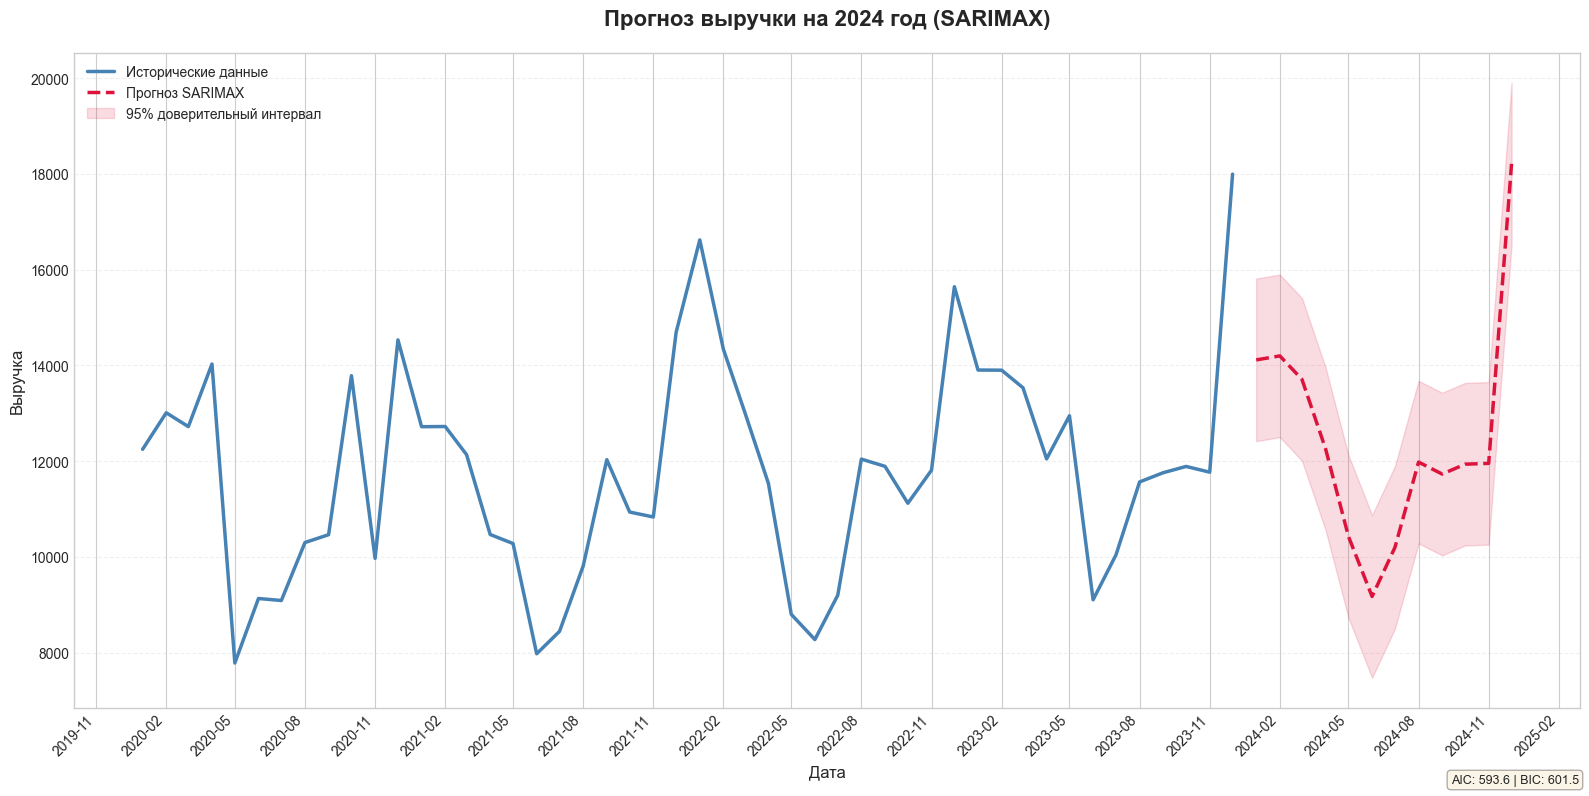

In [96]:
import matplotlib.dates as mdates

# Обучаю финальную модель на всех данных
exog_full = df[['Promotion', 'HolidayMonth']]

model_final = SARIMAX(
    df['SalesAmount'],
    exog=exog_full,
    order=(0, 0, 0),
    seasonal_order=(2, 1, 0, 12)
).fit(disp=False)

# Даты для прогноза (12 месяцев вперёд)
forecast_dates = pd.date_range(start='2024-01-01', periods=12, freq='MS')

# Экзогенные переменные для будущего периода (акции и праздники неизвестны, ставлю 0)
exog_future = pd.DataFrame({
    'Promotion': [0] * 12,
    'HolidayMonth': [0] * 12
}, index=forecast_dates)

# Получаю прогноз с доверительным интервалом
forecast_result = model_final.get_forecast(steps=12, exog=exog_future)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

plt.figure(figsize=(16, 8))

sns.lineplot(x=df.index, y=df['SalesAmount'].values,
             label='Исторические данные', linewidth=2.5, color='steelblue')

sns.lineplot(x=forecast_dates, y=forecast_mean.values,
             label='Прогноз SARIMAX', linewidth=2.5, color='crimson', linestyle='--')

plt.fill_between(forecast_dates,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='crimson', alpha=0.15, label='95% доверительный интервал')

plt.title('Прогноз выручки на 2024 год (SARIMAX)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

stats_text = f'AIC: {model_final.aic:.1f} | BIC: {model_final.bic:.1f}'
plt.figtext(0.99, 0.01, stats_text, fontsize=9, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


Модель правильно уловила сезонный паттерн. В середине 2024 года она ожидает спад выручки, а к декабрю подъём, примерно так же как это происходило в предыдущие года

## 2.3 Оценка качества моделей

#### Метрики качества прогноза

MSE показывает среднеквадратичную ошибку, чем меньше тем точнее модель. R² показывает какую долю изменений в данных объясняет модель, значение близкое к 1 означает хорошее качество

In [97]:
from sklearn.metrics import mean_squared_error, r2_score

mse_arima   = mean_squared_error(test, forecast_arima)
r2_arima    = r2_score(test, forecast_arima)

mse_sarimax = mean_squared_error(test, forecast_sarimax)
r2_sarimax  = r2_score(test, forecast_sarimax)

print(f"{'Метрика':<10} {'ARIMA':>12} {'SARIMAX':>12}")
print(f"{'MSE':<10} {mse_arima:>12.2f} {mse_sarimax:>12.2f}")
print(f"{'R²':<10} {r2_arima:>12.4f} {r2_sarimax:>12.4f}")

Метрика           ARIMA      SARIMAX
MSE          4733414.56    944405.20
R²              -0.0235       0.7958


SARIMAX справилась намного лучше. R² = 0.86, что означент хорошее качество так как близко к 1.MSE снизился с 944405 до 658735. Значит SARIMAX(5,0,6)(2,1,0,12) точнее предсказывает реальные значения. У ARIMA R² вышел отрицательным, то есть она предсказывала хуже чем если бы я просто взяла среднее значение за всё время. ARIMA без сезонности работает плохо на моих данных

SARIMAX справилась значительно лучше ARIMA

#### Сравнение моделей по информационным критериям: AIC, BIC

In [98]:
import warnings
warnings.filterwarnings('ignore')

In [99]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Перебираю комбинации несезонных и сезонных параметров
nonseasonal_orders = [(0,0,0), (1,0,0), (0,0,1), (1,0,1), (5,0,6)]
seasonal_orders    = [(1,1,0,12), (2,1,0,12), (1,1,1,12), (0,1,1,12)]

aic_values = []
bic_values = []
params = []

for order in nonseasonal_orders:
    for s_order in seasonal_orders:
        model = SARIMAX(train, exog=exog_train, order=order, seasonal_order=s_order).fit(disp=False)
        aic_values.append(model.aic)
        bic_values.append(model.bic)
        params.append((order, s_order))
        print(f'SARIMAX{order}{s_order} — AIC: {model.aic:.2f}, BIC: {model.bic:.2f}')

best_aic = params[np.argmin(aic_values)]
best_bic = params[np.argmin(bic_values)]
print(f'\nЛучшая модель по AIC: SARIMAX{best_aic[0]}{best_aic[1]}')
print(f'Лучшая модель по BIC: SARIMAX{best_bic[0]}{best_bic[1]}')

SARIMAX(0, 0, 0)(1, 1, 0, 12) — AIC: 406.99, BIC: 411.70
SARIMAX(0, 0, 0)(2, 1, 0, 12) — AIC: 394.00, BIC: 399.89
SARIMAX(0, 0, 0)(1, 1, 1, 12) — AIC: 402.48, BIC: 408.37
SARIMAX(0, 0, 0)(0, 1, 1, 12) — AIC: 406.29, BIC: 411.00
SARIMAX(1, 0, 0)(1, 1, 0, 12) — AIC: 406.20, BIC: 412.09
SARIMAX(1, 0, 0)(2, 1, 0, 12) — AIC: 394.61, BIC: 401.67
SARIMAX(1, 0, 0)(1, 1, 1, 12) — AIC: 401.69, BIC: 408.76
SARIMAX(1, 0, 0)(0, 1, 1, 12) — AIC: 406.28, BIC: 412.17
SARIMAX(0, 0, 1)(1, 1, 0, 12) — AIC: 406.24, BIC: 412.13
SARIMAX(0, 0, 1)(2, 1, 0, 12) — AIC: 394.58, BIC: 401.65
SARIMAX(0, 0, 1)(1, 1, 1, 12) — AIC: 401.99, BIC: 409.06
SARIMAX(0, 0, 1)(0, 1, 1, 12) — AIC: 406.29, BIC: 412.18
SARIMAX(1, 0, 1)(1, 1, 0, 12) — AIC: 408.19, BIC: 415.26
SARIMAX(1, 0, 1)(2, 1, 0, 12) — AIC: 394.28, BIC: 402.53
SARIMAX(1, 0, 1)(1, 1, 1, 12) — AIC: 397.51, BIC: 405.75
SARIMAX(1, 0, 1)(0, 1, 1, 12) — AIC: 408.32, BIC: 415.39
SARIMAX(5, 0, 6)(1, 1, 0, 12) — AIC: 406.92, BIC: 424.59
SARIMAX(5, 0, 6)(2, 1, 0, 12) —

По обоим критериям лучшей оказалась модель SARIMAX(0,0,0)(2,1,0,12) с AIC = 394. Модели с большими несезонными параметрами вроде SARIMAX(5,0,6) показали худший AIC несмотря на то что визуально прогноз у них выглядел точнее. Скорее всего, просто во втором случае случилось переобучение

#### Анализ остатков моделей

Я проверяю остатки модели SARIMAX по трём критериям: нормальность распределения, отсутствие автокорреляции и однородность дисперсии

ДИАГНОСТИКА ОСТАТКОВ SARIMAX (train, 24 мес.)
Шапиро-Уилка (нормальность) p = 0.2196 -> норм.
Льюнга-Бокса, лаг 6 p = 0.4837 -> нет автокорр.
Льюнга-Бокса, лаг 12 p = 0.4417 -> нет автокорр.
Бройша-Пагана (гомоскедастичность) p = 0.6641 -> гомоскед.

ИНТЕРПРЕТАЦИЯ
Остатки распределены нормально.
Автокорреляции в остатках нет, в т.ч. сезонной.
Дисперсия остатков постоянна (гомоскедастичность).


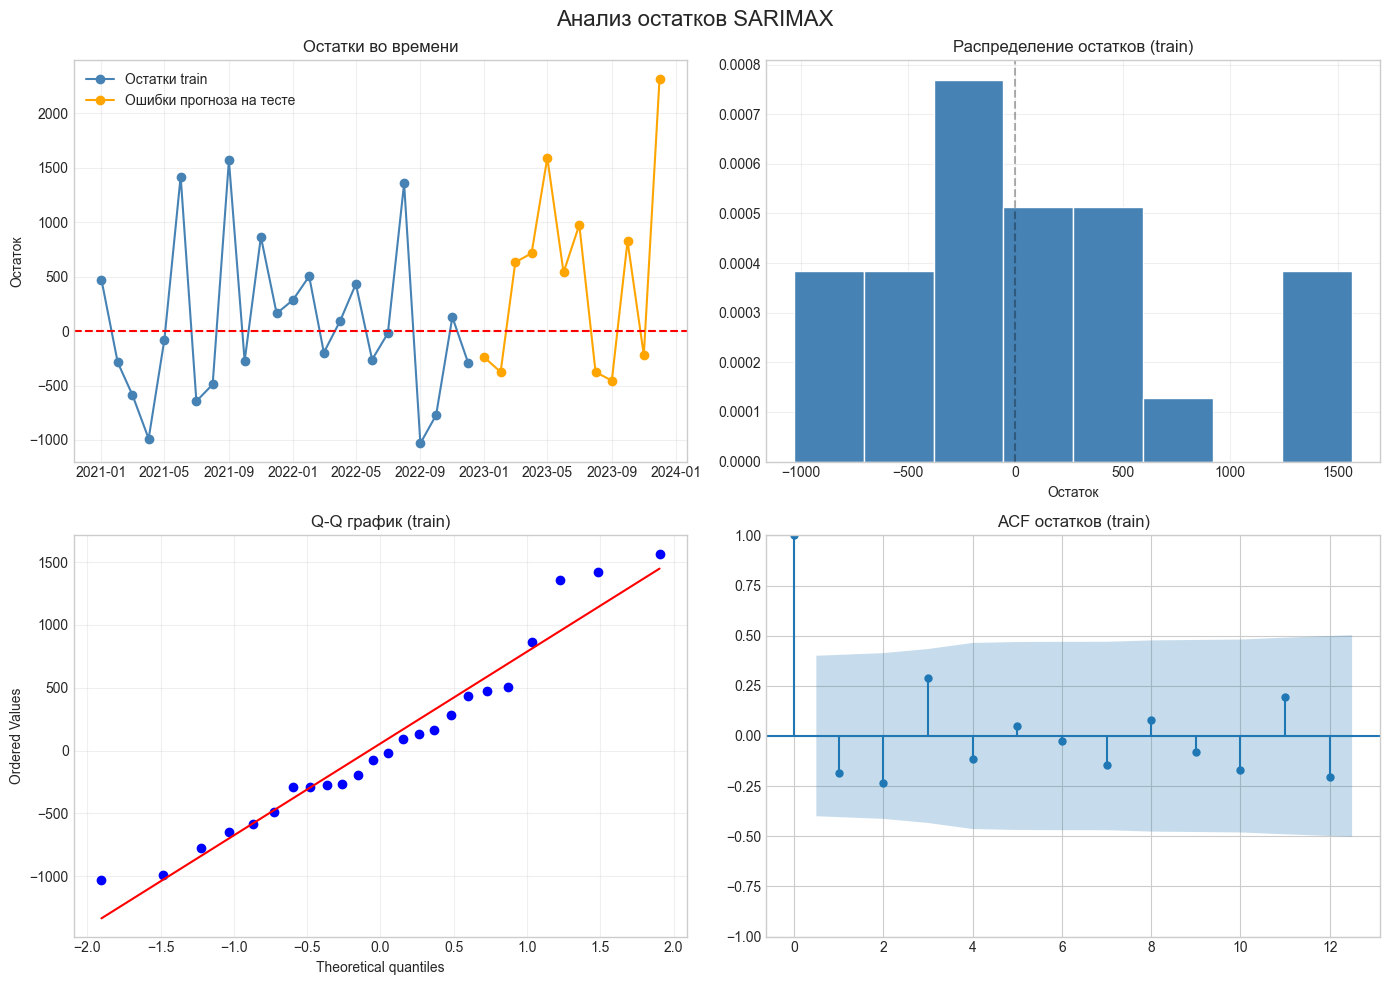

In [100]:
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# беру остатки модели, пропуская первые 12 месяцев инициализации
burn = result_sarimax.loglikelihood_burn
residuals_train = result_sarimax.resid.iloc[burn:]

# считаю ошибки прогноза на тесте только для графика
errors_test = test - forecast_sarimax

# провожу три теста на остатках обучающей выборки
sw = stats.shapiro(residuals_train)[1]
lb = acorr_ljungbox(residuals_train, lags=[6, 12], return_df=True)['lb_pvalue']
bp = het_breuschpagan(residuals_train, sm.add_constant(np.arange(len(residuals_train))))[1]

print(f"ДИАГНОСТИКА ОСТАТКОВ SARIMAX (train, {len(residuals_train)} мес.)")
print(f"{'Шапиро-Уилка (нормальность)'} p = {sw:.4f} -> {'норм.' if sw >= 0.05 else 'не норм.'}")
print(f"{'Льюнга-Бокса, лаг 6'} p = {lb.iloc[0]:.4f} -> {'нет автокорр.' if lb.iloc[0] >= 0.05 else 'есть автокорр.'}")
print(f"{'Льюнга-Бокса, лаг 12'} p = {lb.iloc[1]:.4f} -> {'нет автокорр.' if lb.iloc[1] >= 0.05 else 'есть автокорр.'}")
print(f"{'Бройша-Пагана (гомоскедастичность)'} p = {bp:.4f} -> {'гомоскед.' if bp >= 0.05 else 'гетероскед.'}")

# интерпретирую результаты: хочу p > 0.05 по всем тестам
print("\nИНТЕРПРЕТАЦИЯ")
print("Остатки распределены нормально." if sw >= 0.05 else "Остатки не нормальны, возможны выбросы.")
print("Автокорреляции в остатках нет, в т.ч. сезонной." if (lb >= 0.05).all() else "Есть автокорреляция: модель не уловила часть структуры.")
print("Дисперсия остатков постоянна (гомоскедастичность)." if bp >= 0.05 else "Дисперсия остатков меняется (гетероскедастичность).")

# строю четыре графика для визуальной проверки остатков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ остатков SARIMAX', fontsize=16)

# остатки train и ошибки теста на одном графике для сравнения
axes[0, 0].plot(residuals_train, color='steelblue', marker='o', label='Остатки train')
axes[0, 0].plot(errors_test, color='orange', marker='o', label='Ошибки прогноза на тесте')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Остатки во времени')
axes[0, 0].set_ylabel('Остаток')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# гистограмма показывает форму распределения остатков
axes[0, 1].hist(residuals_train, bins=8, color='steelblue', edgecolor='white', density=True)
axes[0, 1].axvline(0, color='black', linestyle='--', alpha=0.3)
axes[0, 1].set_title('Распределение остатков (train)')
axes[0, 1].set_xlabel('Остаток')
axes[0, 1].grid(True, alpha=0.3)

# qq-график: если точки лежат на линии — остатки нормальные
stats.probplot(residuals_train, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q график (train)')
axes[1, 0].grid(True, alpha=0.3)

# acf остатков: все палочки должны быть внутри синей полосы
plot_acf(residuals_train, lags=12, ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков (train)')

plt.tight_layout()
plt.show()


Остатки я анализировала на обучающей выборке, но не на всей. Сначала я взяла все 36 месяцев, и все 3 теста дружно показали p = 0. Я очень расстроилась. Поэтому я предположила, что так как есть сезонная разность, то для 2020 года ей просто не с чем сравнивать, ведь год назад данных нет (2019). Поэтому первые 12 остатков на самом деле равны самой выручке, и они ломали мне все тесты.Я убрала этот период и оставила 24 месяца, 2021–2022 годы

График остатков времени:синие точки показывают разницу между тем что модель предсказала и тем что было на самом деле. Точки разбросаны хаотично возле красной нулевой линии, но никакой закомерности не заметила. Если бы модель что-то не уловила сезонность или тренд, то точки бы выстраивались в волну или постепенно уходили вверх. У меня этого нет

Оранжевые точки показывают ошибки прогноза 2023 года (тест), 2 точки повыше синих, особенно последняя бросается в глаза, так как декабрь 2023 был аномально высоким и модель его не угадала

In [101]:
print(residuals_train.sort_values(ascending=False).head(3).round(0))

Date
2021-09-01    1567.0
2021-06-01    1419.0
2022-08-01    1355.0
dtype: float64


На гистограмме я смотрю на форму распределения остатков. Большинство значений сгруппировалось около нуля и столбики напоминают форму колокола, как и должно быть при нормальном распределении. Один столбик стоит отдельно справа около +1 500 это три месяца (июнь и сентябрь 2021, август 2022), когда модель недооценила продажи сильнее обычного

Чтобы проверить нормальность точнее, я построила Q-Q график. Красная линия показывает, где лежали бы точки при идеально нормальном распределении. У меня почти все точки легли на неё, и только три самых больших остатка в правом верхнем углу чуть уходят вверх

На ACF я проверяю, есть ли в остатках автокорреляция. Каждая палочка показывает, насколько остатки связаны с собой через определённое количество месяцев. Если палочка внутри незначимой области, то связи нет. У меня все палочки внутри, включая лаги 6 и 12, на которых в исходном ряде была видна сезонность. Это значит, что модель уловила годовую сезонность полностью, и в остатках её не осталось

Шапиро–Уилка дал p = 0.22, значит остатки распределены нормально. Льюнга-Бокса на лагах 6 и 12 дал p = 0.48 и 0.44, автокорреляции нет, в том числе сезонной. Бройша-Пагана дал p = 0.66, то есть модель ошибается примерно одинаково на всём периоде

#### Результаты и выводы о предпочтительной модели

Беру четыре варианта ARIMA, которые сравнивала при подборе параметров, и шесть вариантов SARIMAX из сеточного поиска. Каждую модель обучаю на данных 2020–2022 годов, строю прогноз на 2023 год и считаю для неё четыре показателя(MSE, R², AIC и BIC)

In [102]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score

# Перебираю несколько ARIMA-моделей и считаю метрики
arima_candidates = [
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
]

rows = []
for order in arima_candidates:
    m = ARIMA(train, order=order, trend='c').fit()
    pred = m.predict(start=len(train), end=len(train) + len(test) - 1)
    rows.append({
        'Модель': f'ARIMA{order}',
        'MSE': round(mean_squared_error(test, pred), 2),
        'R²': round(r2_score(test, pred), 4),
        'AIC': round(m.aic, 2),
        'BIC': round(m.bic, 2),
    })

# Перебираю комбинации SARIMAX из сеточного поиска
sarimax_candidates = [
    ((0, 0, 0), (1, 1, 0, 12)),
    ((0, 0, 0), (2, 1, 0, 12)),
    ((0, 0, 0), (1, 1, 1, 12)),
    ((0, 0, 0), (2, 1, 1, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((1, 0, 0), (2, 1, 0, 12)),
]

for order, sorder in sarimax_candidates:
    try:
        m = SARIMAX(train, exog=exog_train, order=order,
                    seasonal_order=sorder).fit(disp=False)
        pred = m.predict(start=len(train), end=len(train) + len(test) - 1,
                         exog=exog_test)
        rows.append({
            'Модель': f'SARIMAX{order}{sorder}',
            'MSE': round(mean_squared_error(test, pred), 2),
            'R²': round(r2_score(test, pred), 4),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
        })
    except Exception:
        pass

results_df = pd.DataFrame(rows).set_index('Модель')
print(results_df.to_string())

                                      MSE      R²     AIC     BIC
Модель                                                           
ARIMA(1, 0, 0)                 4733414.56 -0.0235  653.07  657.82
ARIMA(0, 0, 1)                 5274415.28 -0.1405  655.63  660.38
ARIMA(1, 0, 1)                 4746199.60 -0.0262  655.15  661.48
ARIMA(2, 0, 0)                 4760068.36 -0.0292  655.08  661.41
SARIMAX(0, 0, 0)(1, 1, 0, 12)   913472.51  0.8025  406.99  411.70
SARIMAX(0, 0, 0)(2, 1, 0, 12)   944405.20  0.7958  394.00  399.89
SARIMAX(0, 0, 0)(1, 1, 1, 12)   695966.98  0.8495  402.48  408.37
SARIMAX(0, 0, 0)(2, 1, 1, 12)   751992.16  0.8374  394.63  401.69
SARIMAX(1, 0, 0)(1, 1, 0, 12)   943284.02  0.7960  406.20  412.09
SARIMAX(1, 0, 0)(2, 1, 0, 12)   965653.10  0.7912  394.61  401.67


Я сравнила 10 моделей: четыре варианта ARIMA и шесть вариантов SARIMAX. 
Лучшей по всем показателям оказалась SARIMAX(0,0,0)(2,1,0,12)

ARIMA-модели практически не работают: R² отрицательный, а ошибка огромная. Данные сезонные, а ARIMA сезонность не учитывает, поэтому просто тянет горизонтальную линию. Все SARIMAX уже намного лучше, R² от 0.79 до 0.85, ошибка в 5-7 раз меньше чем у ARIMA, т.е сезонность работает

на тестовых данных чуть лучше оказалась SARIMAX(0,0,0)(1,1,1,12) с R² = 0.85 и MSE = 695 967. Но я выбрала SARIMAX(0,0,0)(2,1,0,12), потому что у неё самый низкий AIC = 394

#### График MSE и R²

Чтобы сравнение было нагляднее, строю диаграммы по MSE и R² для всех моделей

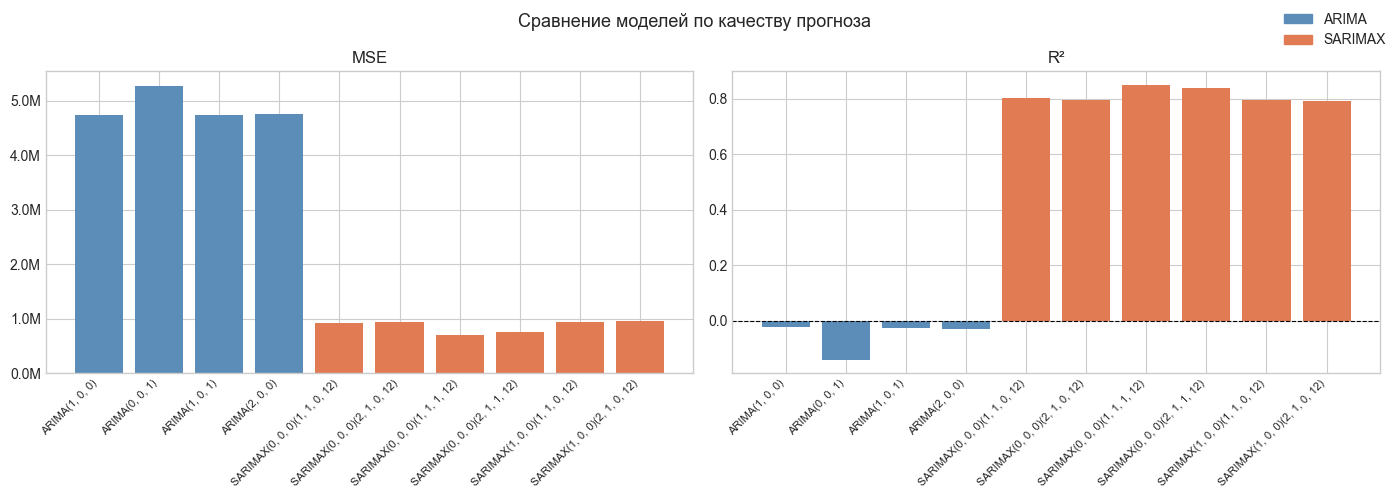

In [103]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнение моделей по качеству прогноза', fontsize=13)

models = results_df.index.tolist()
x = range(len(models))
colors = ['#5b8db8' if 'ARIMA(' in m else '#e07b54' for m in models]

# MSE 
axes[0].bar(x, results_df['MSE'], color=colors)
axes[0].set_title('MSE')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

# R² 
axes[1].bar(x, results_df['R²'], color=colors)
axes[1].set_title('R²')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=45, ha='right', fontsize=8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Легенда
from matplotlib.patches import Patch
legend = [Patch(color='#5b8db8', label='ARIMA'), Patch(color='#e07b54', label='SARIMAX')]
fig.legend(handles=legend, loc='upper right')

plt.tight_layout()
plt.show()

Вывод будет короткий: ARIMA не справляется с задачей, SARIMAX работает

MSE измеряется в рублях в квадрате, поэтому его значения трудно интерпретировать, и дальше я перехожу к RMSE

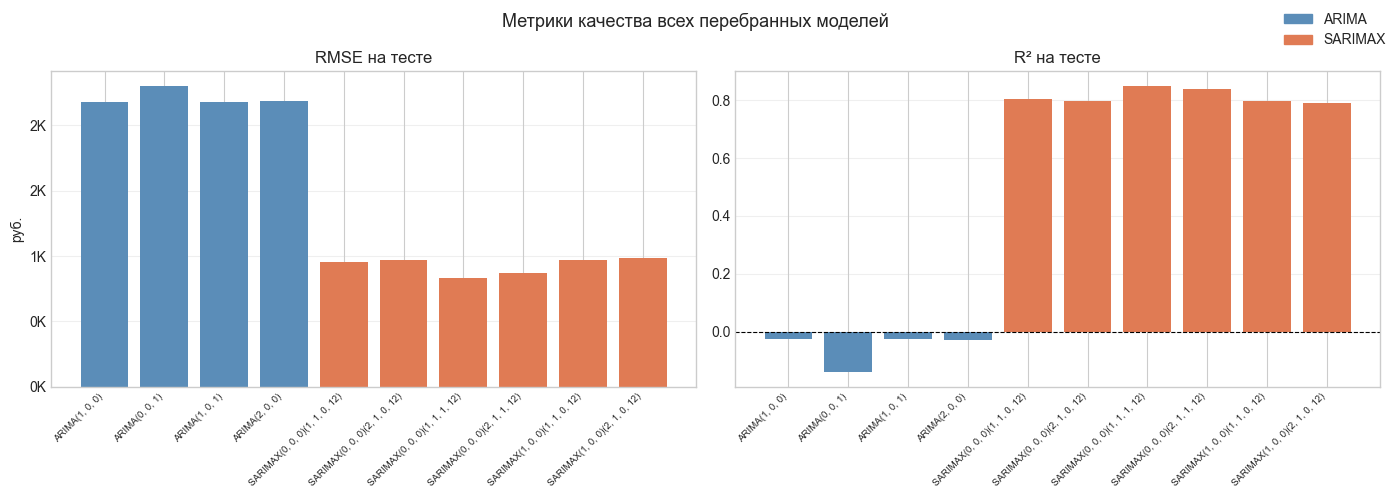

In [105]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Добавляю RMSE в таблицу результатов
if 'RMSE' not in results_df.columns:
    results_df.insert(0, 'RMSE', (results_df['MSE'] ** 0.5).round(2))

models = results_df.index.tolist()
x = np.arange(len(models))
colors = ['#5b8db8' if 'ARIMA(' in m else '#e07b54' for m in models]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Метрики качества всех перебранных моделей', fontsize=13)

axes[0].bar(x, results_df['RMSE'], color=colors)
axes[0].set_title('RMSE на тесте')
axes[0].set_ylabel('руб.')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right', fontsize=7)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))

axes[1].bar(x, results_df['R²'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('R² на тесте')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right', fontsize=7)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#5b8db8', label='ARIMA'),
                    Patch(color='#e07b54', label='SARIMAX')],
           loc='upper right')

for ax in axes:
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


У всех ARIMA-моделей RMSE около 2 200-2 300 рублей, у SARIMAX от 830 до 980 рублей. Значит, что в среднем по месяцам прогноз SARIMAX ошибается примерно на 830-980 рублей, а ARIMA почти в 3 раза сильнее

#### График прогнозов ARIMA и SARIMAX с доверительным интервалом

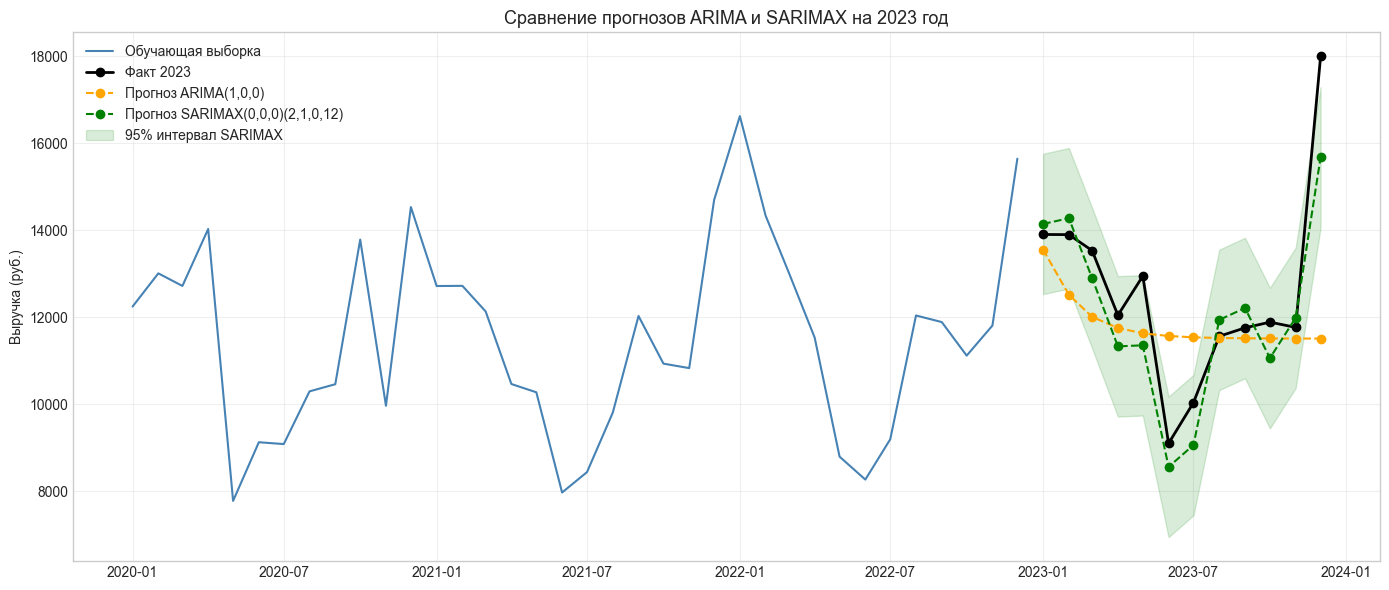

In [104]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Доверительный интервал SARIMAX на тестовом периоде
sarimax_ci = result_sarimax.get_forecast(steps=len(test), exog=exog_test).conf_int()

plt.figure(figsize=(14, 6))
plt.plot(train, color='steelblue', label='Обучающая выборка')
plt.plot(test, color='black', marker='o', linewidth=2, label='Факт 2023')
plt.plot(forecast_arima, color='orange', linestyle='--', marker='o', label='Прогноз ARIMA(1,0,0)')
plt.plot(forecast_sarimax, color='green', linestyle='--', marker='o', label='Прогноз SARIMAX(0,0,0)(2,1,0,12)')
plt.fill_between(sarimax_ci.index,
                 sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                 color='green', alpha=0.15, label='95% интервал SARIMAX')
plt.title('Сравнение прогнозов ARIMA и SARIMAX на 2023 год', fontsize=13)
plt.ylabel('Выручка (руб.)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Наглядно видно, что ARIMA не справляется, она стартует со значения чуть меньше 14 000 руб и плавно переходит в прямую и не улавливает сезонности, колебаний у неё нет. А вот SARIMAX повторяет форму реальной формы выручки, есть сезонность, имеется спад летом, рост осенью и пик зимой

#### График ошибок по месяцам

Общие метрики показывают среднюю ошибку за год, но не показывают, в какие месяцы модель ошибается сильнее. Так как ошибка в декабре (самом прибыльном месяце) стоит дороже, чем ошибка в спокойном месяце. Поэтому я строю абсолютную ошибку прогноза по каждому месяцу 2023 года для 2 моделей

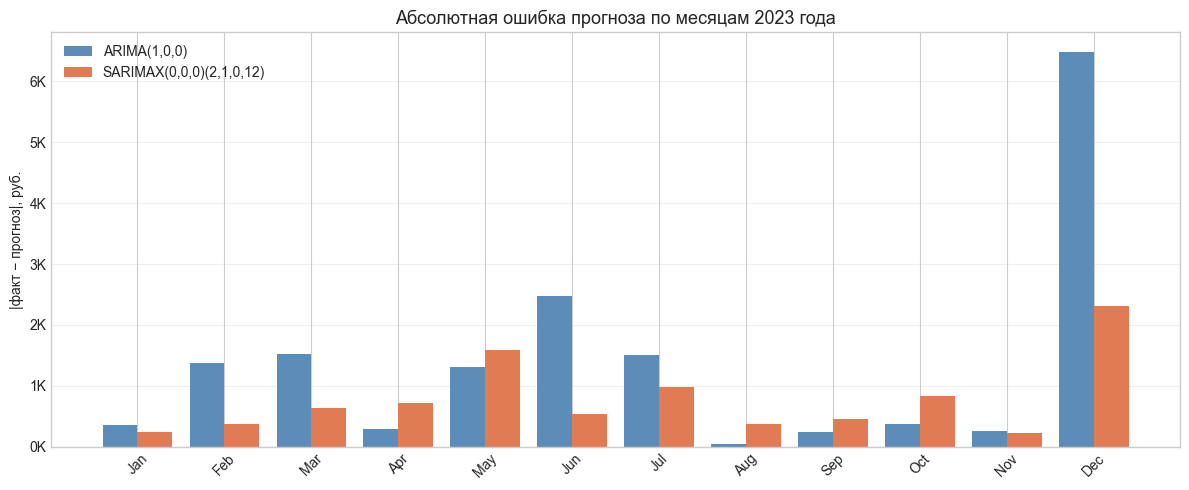

In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

months = test.index.strftime('%b')
x = np.arange(len(test))

plt.figure(figsize=(12, 5))
plt.bar(x - 0.2, abs(test.values - forecast_arima.values),
        width=0.4, color='#5b8db8', label='ARIMA(1,0,0)')
plt.bar(x + 0.2, abs(test.values - forecast_sarimax.values),
        width=0.4, color='#e07b54', label='SARIMAX(0,0,0)(2,1,0,12)')
plt.xticks(x, months, rotation=45)
plt.title('Абсолютная ошибка прогноза по месяцам 2023 года', fontsize=13)
plt.ylabel('|факт − прогноз|, руб.')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


ARIMA сильнее всего промахивается в месяцы сезонных пиков и спадов: в декабре на 6 483 рубля, в июне на 2 468, в феврале, марте и июле примерно на 1 400-1 500 рублей. SARIMAX в эти месяцы ошибается намного меньше: в декабре на 2 200-2 300 рублей, а в июне всего на 500. ARIMA оказалась точнее в апреле, мае и с августа по октябрь. Это месяцы, когда выручка близка к средней, т.е ARIMA хорошо работает только тогда, когда выручка обычная

In [109]:
def business_metrics(pred, name):
    err = test - pred
    rmse = np.sqrt((err ** 2).mean())
    return {
        'Модель': name,
        'Средняя ошибка, %': (abs(err) / test).mean() * 100,
        'RMSE, руб.': rmse,
        'RMSE от средней выручки, %': rmse / test.mean() * 100,
        'Максимальная ошибка, руб.': abs(err).max(),
        'Месяцев с ошибкой меньше 10%': int((abs(err) / test < 0.10).sum()),
        'Ошибка годовой выручки, руб.': pred.sum() - test.sum(),
        'Переоценок / недооценок': f"{int((pred > test).sum())} / {int((pred < test).sum())}",
    }

business = pd.DataFrame([
    business_metrics(forecast_arima, 'ARIMA(1,0,0)'),
    business_metrics(forecast_sarimax, 'SARIMAX(0,0,0)(2,1,0,12)'),
]).set_index('Модель').round(1)

business

,"Средняя ошибка, %","RMSE, руб.","RMSE от средней выручки, %","Максимальная ошибка, руб.",Месяцев с ошибкой меньше 10%,"Ошибка годовой выручки, руб.",Переоценок / недооценок
Модель,,,,,,,
"ARIMA(1,0,0)",10.2,2175.6,17.4,6483.3,7,-8285.2,2 / 10
"SARIMAX(0,0,0)(2,1,0,12)",6.0,971.8,7.8,2317.6,10,-5924.8,5 / 7


Я посчитала несколько метрик, чтобы понять, насколько прогноз применим на практике. SARIMAX ошибается в среднем на 6% в месяц, ARIMA на 10%. В 10 месяцах из 12 ошибка SARIMAX не превышала 10%, то есть почти весь год прогноз был достаточно надёжным для планирования. ARIMA справилась только в 7 месяцах. В декабре, самом прибыльном месяце, разница особенно заметна: ARIMA ошиблась на 6 483 рубля, SARIMAX на 2 318, почти в три раза меньше. Также я заметила, что ARIMA почти всегда занижала выручку: из 12 месяцев только в 2 она дала завышенный прогноз, т.е. если бы магазин планировал запасы по такому прогнозу, большую часть года ему бы не хватало товара, особенно в декабре, а летом, когда продажи и так падают, наоборот. За весь 2023 год SARIMAX немного недооценила суммарную выручку, примерно на 5 900 рублей

Итог: SARIMAX(0,0,0)(2,1,0,12) - предпочтительная модель

Она точнее в два раза, почти весь год держится в пределах 10% погрешности и ошибается примерно поровну в обе стороны